<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/data_reconciliation_bayesian_digital_twin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Plant-data reconciliation and a Bayesian digital twin with NeqSim

This long-form tutorial turns noisy process measurements into an auditable, uncertainty-aware
digital twin. A source-built NeqSim model supplies the thermodynamic and process calculations;
NeqSim's native reconciliation and calibration APIs supply the engineering estimators; and an
independent Python calculation checks the algebra and adds a transparent Bayesian layer.

The data are deliberately synthetic and reproducible. They represent a gas-condensate inlet
separator and an export compressor, not a named asset. Stored outputs are evidence from a clean,
top-to-bottom execution.

## Learning outcomes

After completing the notebook, you can:

1. explain why a steady-state gate must precede steady-state data reconciliation;
2. configure NeqSim's `SteadyStateDetector` from historian-style tag samples;
3. reconcile redundant mass-flow measurements with uncertainty-weighted least squares;
4. verify the native NeqSim result against the closed-form NumPy solution;
5. detect, rank, and isolate a gross sensor error without silently changing raw data;
6. calibrate compressor polytropic efficiency with `BatchParameterEstimator`;
7. form a Bayesian posterior from a validated NeqSim response surface;
8. test the calibrated twin on held-out operating points;
9. propagate parameter uncertainty to compressor power and a teaching constraint; and
10. publish a machine-readable evidence contract with explicit limitations.

## Why this topic belongs in the NeqSim-Colab collection

The collection already contains excellent notebooks on online process simulation, IoT telemetry,
condition monitoring, machine learning, and model-versus-measurement calibration. The missing link
is a dedicated treatment of **measurement trust before model tuning**:

`historian window -> steady-state qualification -> reconciliation -> gross-error isolation ->`
`parameter calibration -> posterior uncertainty -> engineering decision`

This notebook also fulfils the maintenance-ledger follow-up that replaced the retired, corrupted
`syntheticdatageneration.ipynb`: create a current-master data-reconciliation and Bayesian
digital-twin tutorial.

### Engineering boundary

- The example is educational and uses synthetic, non-asset data.
- Pressure is absolute and reported in bara.
- Flow is mass flow in kg/h unless explicitly stated otherwise.
- Measurement uncertainties are one-standard-deviation values.
- The reconciliation constraints are linear, steady-state total-mass balances.
- The Bayesian result quantifies one parameter only: compressor polytropic efficiency.
- Nothing here is a certified meter-validation, custody-transfer, alarm, or equipment-design study.

## 1. Mathematical foundation

### 1.1 Steady-state qualification

The Cao-Rhinehart statistic compares variance in successive differences with ordinary sample
variance. For a window of $n$ measurements $x_i$,

$$\begin{aligned}\sigma_f^2&=\frac{1}{2(n-1)}\sum_{i=2}^{n}(x_i-x_{i-1})^2,\\\sigma_u^2&=\frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^2,\\R&=\frac{\sigma_f^2}{\sigma_u^2}.\end{aligned}$$

White-noise-like variation gives $R$ near one. A trend or step spreads the ordinary variance while
successive changes remain structured, so $R$ is usually smaller. In this tutorial all monitored
tags must have $R\geq0.5$ over a full 20-sample window before reconciliation is allowed.

### 1.2 Weighted least-squares reconciliation

Let $\mathbf{y}$ be measurements, $\mathbf{V}=\mathrm{diag}(\sigma_i^2)$ their covariance matrix,
and $\mathbf{A}\mathbf{x}=\mathbf{0}$ the balance constraints. NeqSim uses

$$\hat{\mathbf{x}}=\mathbf{y}-\mathbf{V}\mathbf{A}^{\mathsf{T}}(\mathbf{A}\mathbf{V}\mathbf{A}^{\mathsf{T}})^{-1}\mathbf{A}\mathbf{y}.$$

The objective $J=(\hat{\mathbf{x}}-\mathbf{y})^{\mathsf{T}}\mathbf{V}^{-1}(\hat{\mathbf{x}}-\mathbf{y})$
supports a global $\chi^2$ consistency test. Per-variable normalized residuals help rank suspect
measurements, but conservation alone does not prove which instrument is faulty.

### 1.3 Bayesian parameter update

For compressor efficiency $\eta$, observations $\mathbf{z}$, and NeqSim predictions
$\mathbf{g}(\eta)$, Bayes' rule is

$$p(\eta\mid\mathbf{z})\propto p(\mathbf{z}\mid\eta)p(\eta).$$

With independent Gaussian temperature errors $\sigma_T$,

$$\log p(\mathbf{z}\mid\eta)=-\frac{1}{2}\sum_j\left(\frac{z_j-g_j(\eta)}{\sigma_T}\right)^2+C.$$

The posterior is computed on a dense one-dimensional grid. A shape-preserving interpolator makes
that grid inexpensive, but every response surface is generated by NeqSim and independently checked
at off-grid efficiencies before it is trusted.

## 2. Clean Colab setup

The released `neqsim` wheel is pinned as the Python/JPype bridge. Advanced calculations use a Java
JAR built from the selected `equinor/neqsim` source ref. A validation runner may supply an exact
checkout and JAR with `NEQSIM_SOURCE_ROOT` and `NEQSIM_SOURCE_JAR`; otherwise this notebook clones
and builds current `master` itself.

In [1]:
import importlib.metadata
import importlib.util
import os
from pathlib import Path
import subprocess
import sys

REQUIRED_PACKAGES = {
    "neqsim": "3.18.0",
}

install_requirements = []
for package_name, required_version in REQUIRED_PACKAGES.items():
    try:
        installed_version = importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        installed_version = None
    if installed_version != required_version:
        install_requirements.append(f"{package_name}=={required_version}")

for module_name in ["matplotlib", "numpy", "pandas", "scipy"]:
    if importlib.util.find_spec(module_name) is None:
        install_requirements.append(module_name)

if install_requirements:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            *install_requirements,
        ],
        check=True,
        timeout=1200,
    )

print("Required Python packages are available.")

Required Python packages are available.


In [2]:
import hashlib
import jpype


def run_command(command, *, cwd=None, timeout=1800, environment=None):
    result = subprocess.run(
        command,
        cwd=cwd,
        env=environment,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        timeout=timeout,
    )
    if result.returncode != 0:
        output_tail = "\n".join(result.stdout.splitlines()[-80:])
        raise RuntimeError(
            f"Command failed ({result.returncode}): {command}\n{output_tail}"
        )
    return result.stdout.strip()


NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
supplied_source_root = os.environ.get("NEQSIM_SOURCE_ROOT", "").strip()
supplied_source_jar = os.environ.get("NEQSIM_SOURCE_JAR", "").strip()

if supplied_source_root and supplied_source_jar:
    neqsim_source_root = Path(supplied_source_root).resolve()
    neqsim_source_jar = Path(supplied_source_jar).resolve()
else:
    runtime_root = Path("/content")
    if not runtime_root.exists():
        runtime_root = Path(os.environ.get("RUNNER_TEMP", "/tmp")).resolve()
    neqsim_source_root = runtime_root / "neqsim-java-master"
    if not neqsim_source_root.exists():
        run_command(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                NEQSIM_SOURCE_REF,
                "https://github.com/equinor/neqsim.git",
                str(neqsim_source_root),
            ],
            timeout=600,
        )
    else:
        run_command(
            ["git", "fetch", "--depth", "1", "origin", NEQSIM_SOURCE_REF],
            cwd=neqsim_source_root,
            timeout=600,
        )
        run_command(
            ["git", "checkout", "--detach", "FETCH_HEAD"],
            cwd=neqsim_source_root,
        )

    maven_settings = runtime_root / "neqsim-maven-settings.xml"
    maven_settings.write_text(
        "<settings><mirrors><mirror><id>canonical-central</id>"
        "<mirrorOf>central</mirrorOf>"
        "<url>https://repo.maven.apache.org/maven2/</url>"
        "</mirror></mirrors></settings>",
        encoding="utf-8",
    )
    run_command(
        [
            "./mvnw",
            "-q",
            "-s",
            str(maven_settings),
            "-DskipTests",
            "-Dmaven.javadoc.skip=true",
            "package",
        ],
        cwd=neqsim_source_root,
        timeout=2400,
    )
    built_jars = [
        path
        for path in (neqsim_source_root / "target").glob("neqsim-*.jar")
        if "sources" not in path.name
        and "javadoc" not in path.name
        and not path.name.startswith("original-")
    ]
    if not built_jars:
        raise FileNotFoundError("Maven completed but no NeqSim JAR was found.")
    neqsim_source_jar = max(
        built_jars,
        key=lambda path: path.stat().st_size,
    )

if not neqsim_source_root.is_dir() or not neqsim_source_jar.is_file():
    raise FileNotFoundError("NeqSim source root or built JAR is missing.")

neqsim_commit = run_command(
    ["git", "rev-parse", "HEAD"],
    cwd=neqsim_source_root,
)
neqsim_jar_sha256 = hashlib.sha256(
    neqsim_source_jar.read_bytes()
).hexdigest()

os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
if not jpype.isJVMStarted():
    jpype.addClassPath(str(neqsim_source_jar))
    jpype.startJVM()

DataReconciliationEngine = jpype.JClass(
    "neqsim.process.util.reconciliation.DataReconciliationEngine"
)
class_source = str(
    DataReconciliationEngine.class_
    .getProtectionDomain()
    .getCodeSource()
    .getLocation()
)
if neqsim_source_jar.name not in class_source:
    raise RuntimeError("NeqSim classes were not loaded from the source-built JAR.")

print("NeqSim source ref:", NEQSIM_SOURCE_REF)
print("NeqSim resolved commit:", neqsim_commit)
print("NeqSim JAR SHA-256:", neqsim_jar_sha256)
print("Loaded reconciliation class from:", class_source)

NeqSim source ref: master
NeqSim resolved commit: fdf6b227b4240589ebbfb900527b37e667f3efc8
NeqSim JAR SHA-256: 070494e0b9488e1c2d1f2ba75c212466346ee6c07eed950001fa5360daecfbd0
Loaded reconciliation class from: file:/workspace/scratch/c5d511e6ac7e/neqsim-source/target/neqsim-3.18.0.jar


In [3]:
import json
import math
import platform

from IPython.display import display
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator

SystemSrkEos = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
ProcessSystem = jpype.JClass("neqsim.process.processmodel.ProcessSystem")
Stream = jpype.JClass("neqsim.process.equipment.stream.Stream")
ThrottlingValve = jpype.JClass(
    "neqsim.process.equipment.valve.ThrottlingValve"
)
Cooler = jpype.JClass("neqsim.process.equipment.heatexchanger.Cooler")
Separator = jpype.JClass("neqsim.process.equipment.separator.Separator")
Compressor = jpype.JClass("neqsim.process.equipment.compressor.Compressor")
ReconciliationVariable = jpype.JClass(
    "neqsim.process.util.reconciliation.ReconciliationVariable"
)
SteadyStateDetector = jpype.JClass(
    "neqsim.process.util.reconciliation.SteadyStateDetector"
)
SteadyStateVariable = jpype.JClass(
    "neqsim.process.util.reconciliation.SteadyStateVariable"
)
BatchParameterEstimator = jpype.JClass(
    "neqsim.process.calibration.BatchParameterEstimator"
)
HashMap = jpype.JClass("java.util.HashMap")

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

RANDOM_SEED = 20260901
TEMPERATURE_NOISE_K = 0.25
TRUE_POLYTROPIC_EFFICIENCY = 0.78
GROSS_ERROR_THRESHOLD = 1.96

figure_directory = Path(
    os.environ.get(
        "NEQSIM_NOTEBOOK_FIGURE_DIR",
        "/tmp/neqsim_data_reconciliation_figures",
    )
)
figure_directory.mkdir(parents=True, exist_ok=True)


def store_figure(figure, file_name):
    output_path = figure_directory / file_name
    figure.savefig(
        output_path,
        dpi=160,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.show()
    return output_path


version_table = pd.DataFrame(
    [
        ("NeqSim Python bridge", importlib.metadata.version("neqsim")),
        ("NeqSim Java commit", neqsim_commit),
        ("Java runtime", str(jpype.java.lang.System.getProperty("java.version"))),
        ("Python", platform.python_version()),
        ("NumPy", np.__version__),
        ("pandas", pd.__version__),
        ("Matplotlib", importlib.metadata.version("matplotlib")),
        ("SciPy", importlib.metadata.version("scipy")),
    ],
    columns=["Dependency", "Resolved version or identity"],
)
display(version_table)

,Dependency,Resolved version or identity
0,NeqSim Python bridge,3.18.0
1,NeqSim Java commit,fdf6b227b4240589ebbfb900527b37e667f3efc8
2,Java runtime,17.0.20
3,Python,3.12.13
4,NumPy,2.5.2
5,pandas,3.0.5
6,Matplotlib,3.10.8
7,SciPy,1.17.0


## 3. Build the source process model

The first model represents a gas-condensate wellstream entering a high-pressure facility. A valve
and cooler establish the separator condition. The separator gas is compressed to export pressure;
the hydrocarbon liquid leaves as a separate measured product.

### Model basis

| Item | Value | Interpretation |
|---|---:|---|
| EOS | SRK | Cubic EOS for a teaching gas-condensate case |
| Mixing rule | classic | Default cubic-EOS interaction treatment |
| Feed pressure | 85 bara | Absolute inlet pressure |
| Feed temperature | 45 °C | Warm wellstream |
| Feed mass flow | 60,000 kg/h | Total inlet mass rate |
| Separator | 45 bara, 20 °C | Pressure letdown followed by cooling |
| Compressor outlet | 100 bara | Illustrative export target |
| Compressor efficiency | 0.78 | Synthetic truth used later |

The composition is on a molar basis and is normalized explicitly before it is passed to NeqSim.

In [4]:
feed_composition_mol_pct = {
    "nitrogen": 1.0,
    "CO2": 2.0,
    "methane": 68.0,
    "ethane": 10.0,
    "propane": 7.0,
    "i-butane": 2.0,
    "n-butane": 3.0,
    "i-pentane": 1.5,
    "n-pentane": 1.5,
    "n-hexane": 1.5,
    "n-heptane": 1.5,
}

composition_total = sum(feed_composition_mol_pct.values())
normalized_composition = {
    component: value / composition_total
    for component, value in feed_composition_mol_pct.items()
}

composition_table = pd.DataFrame(
    {
        "Component": list(normalized_composition),
        "Mole fraction": list(normalized_composition.values()),
        "Mole percent": [
            100.0 * value
            for value in normalized_composition.values()
        ],
    }
)
display(composition_table)
print("Normalized mole-fraction sum:", sum(normalized_composition.values()))

Normalized mole-fraction sum: 1.0


,Component,Mole fraction,Mole percent
0,nitrogen,0.010101,1.010101
1,CO2,0.020202,2.020202
2,methane,0.686869,68.686869
3,ethane,0.101010,10.101010
4,propane,0.070707,7.070707
5,i-butane,0.020202,2.020202
6,n-butane,0.030303,3.030303
7,i-pentane,0.015152,1.515152
8,n-pentane,0.015152,1.515152
9,n-hexane,0.015152,1.515152


In [5]:
def build_inlet_process():
    fluid = SystemSrkEos(45.0 + 273.15, 85.0)
    for component, mole_fraction in normalized_composition.items():
        fluid.addComponent(component, float(mole_fraction))
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)

    feed_stream = Stream("feed_stream", fluid)
    feed_stream.setFlowRate(60000.0, "kg/hr")
    feed_stream.setTemperature(45.0, "C")
    feed_stream.setPressure(85.0, "bara")

    inlet_valve = ThrottlingValve("inlet_valve", feed_stream)
    inlet_valve.setOutletPressure(45.0, "bara")

    inlet_cooler = Cooler("inlet_cooler", inlet_valve.getOutletStream())
    inlet_cooler.setOutTemperature(20.0 + 273.15)

    inlet_separator = Separator(
        "inlet_separator",
        inlet_cooler.getOutletStream(),
    )

    export_compressor = Compressor(
        "process_export_compressor",
        inlet_separator.getGasOutStream(),
    )
    export_compressor.setUsePolytropicCalc(True)
    export_compressor.setPolytropicEfficiency(
        TRUE_POLYTROPIC_EFFICIENCY
    )
    export_compressor.setOutletPressure(100.0, "bara")

    process = ProcessSystem("inlet_reconciliation_process")
    for unit in [
        feed_stream,
        inlet_valve,
        inlet_cooler,
        inlet_separator,
        export_compressor,
    ]:
        process.add(unit)
    process.run()

    return {
        "process": process,
        "feed": feed_stream,
        "valve": inlet_valve,
        "cooler": inlet_cooler,
        "separator": inlet_separator,
        "compressor": export_compressor,
    }


inlet_model = build_inlet_process()
feed_stream = inlet_model["feed"]
inlet_separator = inlet_model["separator"]
process_export_compressor = inlet_model["compressor"]

separator_gas_stream = inlet_separator.getGasOutStream()
separator_liquid_stream = inlet_separator.getLiquidOutStream()
export_gas_stream = process_export_compressor.getOutletStream()

true_mass_flows_kg_h = {
    "feed": float(feed_stream.getFlowRate("kg/hr")),
    "separator_gas": float(separator_gas_stream.getFlowRate("kg/hr")),
    "separator_liquid": float(
        separator_liquid_stream.getFlowRate("kg/hr")
    ),
    "export_gas": float(export_gas_stream.getFlowRate("kg/hr")),
    "export_liquid": float(
        separator_liquid_stream.getFlowRate("kg/hr")
    ),
}

process_mass_residual_kg_h = (
    true_mass_flows_kg_h["feed"]
    - true_mass_flows_kg_h["separator_gas"]
    - true_mass_flows_kg_h["separator_liquid"]
)

base_result_table = pd.DataFrame(
    [
        (
            "Feed",
            true_mass_flows_kg_h["feed"],
            float(feed_stream.getPressure("bara")),
            float(feed_stream.getTemperature("C")),
        ),
        (
            "Separator gas",
            true_mass_flows_kg_h["separator_gas"],
            float(separator_gas_stream.getPressure("bara")),
            float(separator_gas_stream.getTemperature("C")),
        ),
        (
            "Separator liquid",
            true_mass_flows_kg_h["separator_liquid"],
            float(separator_liquid_stream.getPressure("bara")),
            float(separator_liquid_stream.getTemperature("C")),
        ),
        (
            "Export gas",
            true_mass_flows_kg_h["export_gas"],
            float(export_gas_stream.getPressure("bara")),
            float(export_gas_stream.getTemperature("C")),
        ),
    ],
    columns=[
        "Stream",
        "Mass flow [kg/h]",
        "Pressure [bara]",
        "Temperature [°C]",
    ],
)
display(base_result_table)
print("Separator mass residual [kg/h]:", process_mass_residual_kg_h)
print(
    "Compressor power [MW]:",
    float(process_export_compressor.getPower("MW")),
)

Separator mass residual [kg/h]: -8.298593456856906e-08
Compressor power [MW]: 1.287039437453317


,Stream,Mass flow [kg/h],Pressure [bara],Temperature [°C]
0,Feed,60000.000000,85.0,45.000000
1,Separator gas,40717.078499,45.0,20.000000
2,Separator liquid,19282.921501,45.0,20.000000
3,Export gas,40717.078499,100.0,87.379134


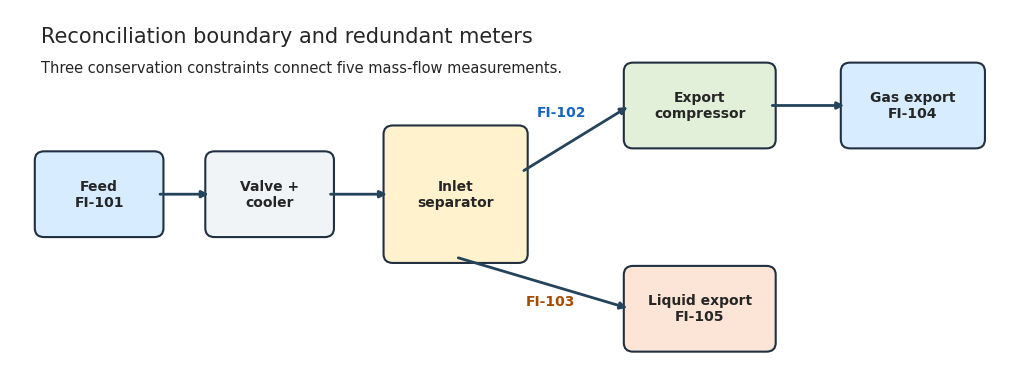

In [6]:
figure, axis = plt.subplots(figsize=(13.0, 4.8))
axis.set_xlim(0.0, 13.0)
axis.set_ylim(0.0, 5.0)
axis.axis("off")


def draw_unit(x_position, y_position, width, height, label, color):
    patch = FancyBboxPatch(
        (x_position, y_position),
        width,
        height,
        boxstyle="round,pad=0.08,rounding_size=0.12",
        linewidth=1.5,
        edgecolor="#203040",
        facecolor=color,
    )
    axis.add_patch(patch)
    axis.text(
        x_position + width / 2.0,
        y_position + height / 2.0,
        label,
        ha="center",
        va="center",
        fontsize=10,
        weight="bold",
    )


draw_unit(0.4, 2.0, 1.5, 1.0, "Feed\nFI-101", "#d7ecff")
draw_unit(2.6, 2.0, 1.5, 1.0, "Valve +\ncooler", "#f1f4f7")
draw_unit(4.9, 1.65, 1.7, 1.7, "Inlet\nseparator", "#fff2cc")
draw_unit(8.0, 3.2, 1.8, 1.0, "Export\ncompressor", "#e2f0d9")
draw_unit(10.8, 3.2, 1.7, 1.0, "Gas export\nFI-104", "#d7ecff")
draw_unit(8.0, 0.45, 1.8, 1.0, "Liquid export\nFI-105", "#fce4d6")

arrow_style = {
    "arrowstyle": "-|>",
    "linewidth": 2.0,
    "color": "#24445c",
}
axis.annotate("", xy=(2.6, 2.5), xytext=(1.9, 2.5), arrowprops=arrow_style)
axis.annotate("", xy=(4.9, 2.5), xytext=(4.1, 2.5), arrowprops=arrow_style)
axis.annotate("", xy=(8.0, 3.7), xytext=(6.6, 2.8), arrowprops=arrow_style)
axis.annotate("", xy=(10.8, 3.7), xytext=(9.8, 3.7), arrowprops=arrow_style)
axis.annotate("", xy=(8.0, 0.95), xytext=(5.75, 1.65), arrowprops=arrow_style)

axis.text(6.8, 3.55, "FI-102", color="#1565c0", weight="bold")
axis.text(6.65, 1.0, "FI-103", color="#a64b00", weight="bold")
axis.text(0.4, 4.55, "Reconciliation boundary and redundant meters", fontsize=15)
axis.text(
    0.4,
    4.15,
    "Three conservation constraints connect five mass-flow measurements.",
    fontsize=10.5,
)

process_schematic_path = store_figure(
    figure,
    "01_process_and_meter_topology.png",
)

### Interpretation of the process and meter topology

**Observation.** The calculated feed splits into about 40.7 t/h gas and 19.3 t/h liquid, and the
compressor preserves gas mass flow. The native separator residual is far below instrument
resolution.

**Physical mechanism.** Pressure reduction and cooling move the heavier components into a liquid
phase. The compressor changes gas enthalpy and pressure but not steady-state mass flow.

**Engineering implication.** FI-102 and FI-104 measure nominally the same gas mass rate on either
side of the compressor, while FI-103 and FI-105 duplicate the liquid path. That redundancy makes
the measurement network testable.

**Recommendation.** Preserve meter location, unit, uncertainty, time basis, and process boundary in
the tag contract. A number without that semantic context is not safe to reconcile.

## 4. Qualify a historian window before reconciliation

The synthetic history contains startup, a stable period, a small production disturbance, recovery,
and a final stable period. Noise is scaled by the stated meter uncertainties. The detector evaluates
all three primary flow tags after every sample, but `requireFullWindow=True` prevents an early pass.

In [7]:
history_rng = np.random.default_rng(RANDOM_SEED)
sample_count = 120
sample_index = np.arange(sample_count)

rate_scale = np.ones(sample_count)
rate_scale[:30] = np.linspace(0.94, 1.0, 30)
rate_scale[70:80] = np.linspace(1.0, 0.97, 10)
rate_scale[80:90] = np.linspace(0.97, 1.0, 10)

history_tag_names = ["feed", "separator_gas", "separator_liquid"]
history_true_values = np.array(
    [true_mass_flows_kg_h[name] for name in history_tag_names],
    dtype=float,
)
history_uncertainties = np.array([180.0, 140.0, 90.0])

history_measurements = (
    rate_scale[:, np.newaxis] * history_true_values[np.newaxis, :]
    + history_rng.normal(
        0.0,
        history_uncertainties,
        size=(sample_count, len(history_tag_names)),
    )
)

steady_state_detector = SteadyStateDetector(20)
steady_state_detector.setRThreshold(0.5)
steady_state_detector.setRequireFullWindow(True)

for tag_name, uncertainty in zip(
    history_tag_names,
    history_uncertainties,
):
    variable = SteadyStateVariable(tag_name, 20)
    variable.setUnit("kg/hr")
    variable.setUncertainty(float(uncertainty))
    steady_state_detector.addVariable(variable)

steady_state_flags = []
r_statistic_records = []

for sample_values in history_measurements:
    for tag_name, measured_value in zip(
        history_tag_names,
        sample_values,
    ):
        steady_state_detector.updateVariable(
            tag_name,
            float(measured_value),
        )
    detector_result = steady_state_detector.evaluate()
    steady_state_flags.append(bool(detector_result.isAtSteadyState()))
    r_statistic_records.append(
        [
            float(variable.getRStatistic())
            for variable in detector_result.getVariables()
        ]
    )

steady_state_flags = np.asarray(steady_state_flags, dtype=bool)
r_statistic_records = np.asarray(r_statistic_records, dtype=float)

history_table = pd.DataFrame(
    history_measurements,
    columns=[f"{name} [kg/h]" for name in history_tag_names],
)
history_table.insert(0, "Sample", sample_index)
history_table["All tags steady"] = steady_state_flags

first_steady_sample = int(np.flatnonzero(steady_state_flags)[0])
final_window_is_steady = bool(steady_state_flags[-1])

print("First all-tag steady-state sample:", first_steady_sample)
print("Final window accepted:", final_window_is_steady)
display(history_table.tail(10))

First all-tag steady-state sample: 46
Final window accepted: True


,Sample,feed [kg/h],separator_gas [kg/h],separator_liquid [kg/h],All tags steady
110,110,60061.402609,40537.157356,19325.368047,True
111,111,60020.529403,40523.803541,19304.719790,True
112,112,60178.357174,40854.851800,19146.978293,True
113,113,60022.855989,40780.074353,19333.004595,True
114,114,59813.453092,40532.920145,19283.813315,True
115,115,60007.358207,40696.993438,19227.809911,True
116,116,59767.123474,40798.006768,19178.644432,True
117,117,59796.585249,40537.956409,19249.131511,True
118,118,60224.213512,40838.263150,19239.175334,True
119,119,59903.538563,40871.316934,19186.228207,True


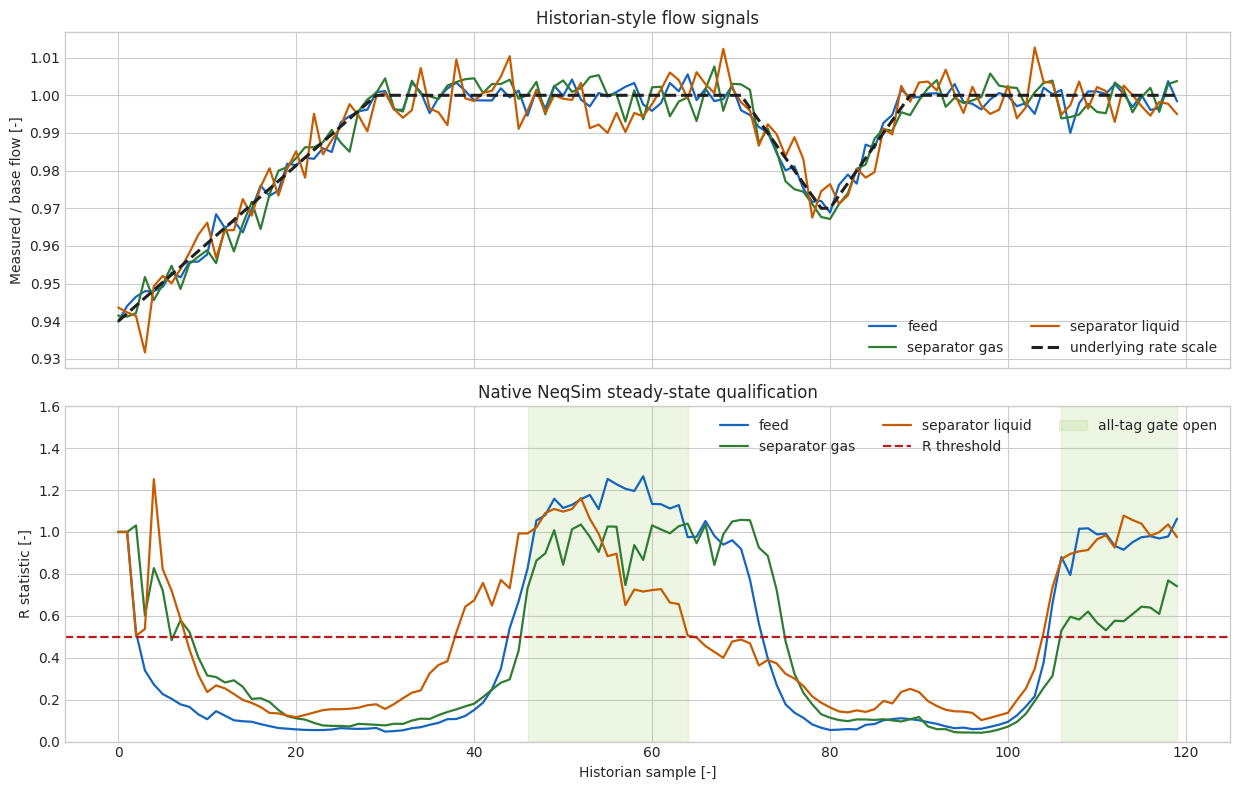

In [8]:
figure, axes = plt.subplots(2, 1, figsize=(12.5, 8.0), sharex=True)

colors = ["#1565c0", "#2e7d32", "#c75b00"]
for variable_index, (tag_name, color) in enumerate(
    zip(history_tag_names, colors)
):
    normalized_flow = (
        history_measurements[:, variable_index]
        / history_true_values[variable_index]
    )
    axes[0].plot(
        sample_index,
        normalized_flow,
        label=tag_name.replace("_", " "),
        color=color,
        linewidth=1.6,
    )
    axes[1].plot(
        sample_index,
        r_statistic_records[:, variable_index],
        label=tag_name.replace("_", " "),
        color=color,
        linewidth=1.6,
    )

axes[0].plot(
    sample_index,
    rate_scale,
    color="#202020",
    linewidth=2.2,
    linestyle="--",
    label="underlying rate scale",
)
axes[0].set_ylabel("Measured / base flow [-]")
axes[0].set_title("Historian-style flow signals")
axes[0].legend(ncol=2, loc="best")

axes[1].axhline(
    0.5,
    color="#b71c1c",
    linestyle="--",
    linewidth=1.6,
    label="R threshold",
)
axes[1].fill_between(
    sample_index,
    0.0,
    1.6,
    where=steady_state_flags,
    color="#9ccc65",
    alpha=0.18,
    label="all-tag gate open",
)
axes[1].set_ylim(0.0, 1.6)
axes[1].set_xlabel("Historian sample [-]")
axes[1].set_ylabel("R statistic [-]")
axes[1].set_title("Native NeqSim steady-state qualification")
axes[1].legend(ncol=3, loc="upper right")

figure.tight_layout()
steady_state_figure_path = store_figure(
    figure,
    "02_steady_state_detection.png",
)

### Interpretation of the steady-state gate

**Observation.** Startup and the temporary 3% disturbance drive one or more $R$ statistics below
0.5. The detector reopens only after a full stable window has replaced the transient samples.

**Physical mechanism.** A ramp creates coherent low-frequency variation, so ordinary variance
grows relative to variance in successive differences. Once only white-noise-like samples remain,
the ratio recovers toward one.

**Engineering implication.** A reconciliation engine can always force a mathematical balance, but
balancing a transient inventory change would mislabel real accumulation as sensor error.

**Recommendation.** Gate each reconciliation snapshot with the tags and time constants relevant to
the chosen boundary. For vessels with material inventory, use dynamic balances rather than merely
loosening the steady-state threshold.

## 5. Reconcile the redundant mass-flow network

Five meters and three constraints define the normal problem:

$$\begin{aligned}F_{\mathrm{feed}}-F_{\mathrm{sep,g}}-F_{\mathrm{sep,l}}&=0,\\F_{\mathrm{sep,g}}-F_{\mathrm{export,g}}&=0,\\F_{\mathrm{sep,l}}-F_{\mathrm{export,l}}&=0.\end{aligned}$$

The synthetic noise is intentionally deterministic. The raw measurements are never overwritten;
reconciled values and diagnostic statistics are stored in separate columns.

In [9]:
reconciliation_names = [
    "feed",
    "separator_gas",
    "separator_liquid",
    "export_gas",
    "export_liquid",
]

true_flow_vector_kg_h = np.array(
    [true_mass_flows_kg_h[name] for name in reconciliation_names],
    dtype=float,
)
measurement_uncertainty_kg_h = np.array(
    [180.0, 140.0, 90.0, 130.0, 85.0],
    dtype=float,
)
normal_noise_kg_h = np.array(
    [45.0, -35.0, 25.0, 30.0, -20.0],
    dtype=float,
)
normal_measurements_kg_h = true_flow_vector_kg_h + normal_noise_kg_h

constraint_matrix = np.array(
    [
        [1.0, -1.0, -1.0, 0.0, 0.0],
        [0.0, 1.0, 0.0, -1.0, 0.0],
        [0.0, 0.0, 1.0, 0.0, -1.0],
    ],
    dtype=float,
)


def run_native_reconciliation(
    names,
    measured_values,
    uncertainties,
    constraints,
):
    engine = DataReconciliationEngine()
    engine.setGrossErrorThreshold(GROSS_ERROR_THRESHOLD)
    for name, measured_value, uncertainty in zip(
        names,
        measured_values,
        uncertainties,
    ):
        engine.addVariable(
            ReconciliationVariable(
                name,
                float(measured_value),
                float(uncertainty),
            )
        )
    for constraint_number, constraint in enumerate(constraints, start=1):
        engine.addConstraint(
            constraint.tolist(),
            f"mass_balance_{constraint_number}",
        )
    result = engine.reconcile()
    variables = list(engine.getVariables())
    reconciled_values = np.array(
        [float(variable.getReconciledValue()) for variable in variables]
    )
    normalized_residuals = np.array(
        [float(variable.getNormalizedResidual()) for variable in variables]
    )
    return engine, result, reconciled_values, normalized_residuals


def solve_wls_with_numpy(measured_values, uncertainties, constraints):
    covariance = np.diag(np.square(uncertainties))
    residual = constraints @ measured_values
    gain_system = constraints @ covariance @ constraints.T
    lagrange_multipliers = np.linalg.solve(gain_system, residual)
    correction = covariance @ constraints.T @ lagrange_multipliers
    return measured_values - correction


(
    normal_engine,
    normal_result,
    normal_reconciled_kg_h,
    normal_normalized_residuals,
) = run_native_reconciliation(
    reconciliation_names,
    normal_measurements_kg_h,
    measurement_uncertainty_kg_h,
    constraint_matrix,
)

numpy_reconciled_kg_h = solve_wls_with_numpy(
    normal_measurements_kg_h,
    measurement_uncertainty_kg_h,
    constraint_matrix,
)

native_numpy_max_difference_kg_h = float(
    np.max(np.abs(normal_reconciled_kg_h - numpy_reconciled_kg_h))
)
normal_balance_before_kg_h = constraint_matrix @ normal_measurements_kg_h
normal_balance_after_kg_h = constraint_matrix @ normal_reconciled_kg_h

normal_reconciliation_table = pd.DataFrame(
    {
        "Tag": reconciliation_names,
        "True [kg/h]": true_flow_vector_kg_h,
        "Measured [kg/h]": normal_measurements_kg_h,
        "Sigma [kg/h]": measurement_uncertainty_kg_h,
        "Reconciled [kg/h]": normal_reconciled_kg_h,
        "Adjustment [kg/h]": (
            normal_reconciled_kg_h - normal_measurements_kg_h
        ),
        "Normalized residual [-]": normal_normalized_residuals,
    }
)

display(normal_reconciliation_table.round(4))
print("Native result converged:", bool(normal_result.isConverged()))
print("Global chi-square test passed:", bool(normal_result.isGlobalTestPassed()))
print("Chi-square statistic:", float(normal_result.getChiSquareStatistic()))
print("Maximum native-vs-NumPy difference [kg/h]:", native_numpy_max_difference_kg_h)
print("Maximum post-reconciliation closure [kg/h]:", np.max(np.abs(normal_balance_after_kg_h)))

Native result converged: True
Global chi-square test passed: True
Chi-square statistic: 0.2904018361751536
Maximum native-vs-NumPy difference [kg/h]: 7.275957614183426e-12
Maximum post-reconciliation closure [kg/h]: 7.275957614183426e-12


,Tag,True [kg/h],Measured [kg/h],Sigma [kg/h],Reconciled [kg/h],Adjustment [kg/h],Normalized residual [-]
0,feed,60000.0000,60045.0000,180.0,60013.6110,-31.3890,-0.2062
1,separator_gas,40717.0785,40682.0785,140.0,40725.7745,43.6960,0.3933
2,separator_liquid,19282.9215,19307.9215,90.0,19287.8364,-20.0851,-0.2960
3,export_gas,40717.0785,40747.0785,130.0,40725.7745,-21.3040,-0.2169
4,export_liquid,19282.9215,19262.9215,85.0,19287.8364,24.9149,0.4080


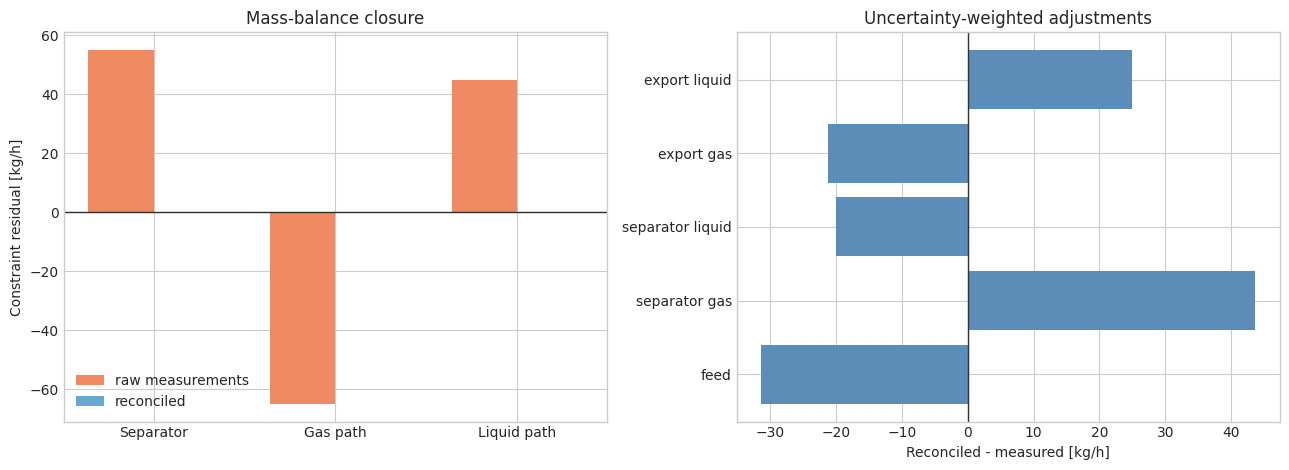

In [10]:
figure, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
constraint_labels = [
    "Separator",
    "Gas path",
    "Liquid path",
]
x_positions = np.arange(len(constraint_labels))
bar_width = 0.36

axes[0].bar(
    x_positions - bar_width / 2.0,
    normal_balance_before_kg_h,
    width=bar_width,
    color="#ef8a62",
    label="raw measurements",
)
axes[0].bar(
    x_positions + bar_width / 2.0,
    normal_balance_after_kg_h,
    width=bar_width,
    color="#67a9cf",
    label="reconciled",
)
axes[0].axhline(0.0, color="#303030", linewidth=1.0)
axes[0].set_xticks(x_positions, constraint_labels)
axes[0].set_ylabel("Constraint residual [kg/h]")
axes[0].set_title("Mass-balance closure")
axes[0].legend()

adjustments = normal_reconciled_kg_h - normal_measurements_kg_h
axes[1].barh(
    [name.replace("_", " ") for name in reconciliation_names],
    adjustments,
    color="#5b8db8",
)
axes[1].axvline(0.0, color="#303030", linewidth=1.0)
axes[1].set_xlabel("Reconciled - measured [kg/h]")
axes[1].set_title("Uncertainty-weighted adjustments")

figure.tight_layout()
reconciliation_figure_path = store_figure(
    figure,
    "03_normal_reconciliation.png",
)

### Interpretation of normal reconciliation

**Observation.** All three raw balance residuals are modest relative to their combined uncertainty.
The global test passes, and the adjusted values close every constraint to numerical precision. The
native solution and independent NumPy equation agree to floating-point tolerance.

**Physical mechanism.** WLS distributes each imbalance according to meter variance. A meter with
larger uncertainty moves more because doing so costs less in the normalized objective.

**Engineering implication.** Reconciled values are statistically consistent estimates, not proof
that the physical model is correct. The result is only as defensible as its boundary, units,
uncertainties, covariance assumptions, and steady-state qualification.

**Recommendation.** Retain raw and reconciled values side by side, version the constraint matrix,
and investigate uncertainty estimates that force one meter to absorb nearly every correction.

## 6. Detect and isolate a gross sensor error

FI-102 (`separator_gas`) is now biased upward by 600 kg/h. That is only about 1.5% of the gas rate,
but it conflicts with both the separator balance and the downstream gas meter. The example uses the
current API signature `reconcileWithGrossErrorElimination(1)` for diagnostic reporting, then forms a
new reduced problem after the candidate has been isolated.

In [11]:
biased_measurements_kg_h = normal_measurements_kg_h.copy()
separator_gas_index = reconciliation_names.index("separator_gas")
biased_measurements_kg_h[separator_gas_index] += 600.0

(
    biased_engine,
    biased_result,
    biased_reconciled_kg_h,
    biased_normalized_residuals,
) = run_native_reconciliation(
    reconciliation_names,
    biased_measurements_kg_h,
    measurement_uncertainty_kg_h,
    constraint_matrix,
)

diagnostic_result = biased_engine.reconcileWithGrossErrorElimination(1)
diagnostic_gross_errors = [
    str(variable.getName())
    for variable in diagnostic_result.getGrossErrors()
]
worst_residual_index = int(
    np.argmax(np.abs(biased_normalized_residuals))
)
worst_residual_tag = reconciliation_names[worst_residual_index]

biased_reconciliation_table = pd.DataFrame(
    {
        "Tag": reconciliation_names,
        "True [kg/h]": true_flow_vector_kg_h,
        "Biased measurement [kg/h]": biased_measurements_kg_h,
        "Reconciled [kg/h]": biased_reconciled_kg_h,
        "Normalized residual [-]": biased_normalized_residuals,
        "Flagged": np.abs(biased_normalized_residuals) > GROSS_ERROR_THRESHOLD,
    }
)

display(biased_reconciliation_table.round(4))
print("Global test passed:", bool(biased_result.isGlobalTestPassed()))
print("Diagnostic gross-error list:", diagnostic_gross_errors)
print("Largest normalized residual:", worst_residual_tag)

Global test passed: False
Diagnostic gross-error list: ['separator_gas', 'export_gas']
Largest normalized residual: separator_gas


,Tag,True [kg/h],Biased measurement [kg/h],Reconciled [kg/h],Normalized residual [-],Flagged
0,feed,60000.0000,60045.0000,60212.3353,1.0992,False
1,separator_gas,40717.0785,41282.0785,40947.9211,-3.0077,True
2,separator_liquid,19282.9215,19307.9215,19264.4142,-0.6413,False
3,export_gas,40717.0785,40747.0785,40947.9211,2.0452,True
4,export_liquid,19282.9215,19262.9215,19264.4142,0.0244,False


In [12]:
reduced_names = [
    "feed",
    "separator_liquid",
    "export_gas",
    "export_liquid",
]
reduced_indices = [
    reconciliation_names.index(name)
    for name in reduced_names
]
reduced_measurements_kg_h = biased_measurements_kg_h[reduced_indices]
reduced_uncertainties_kg_h = measurement_uncertainty_kg_h[reduced_indices]
reduced_constraints = np.array(
    [
        [1.0, -1.0, -1.0, 0.0],
        [0.0, 1.0, 0.0, -1.0],
    ],
    dtype=float,
)

(
    reduced_engine,
    reduced_result,
    reduced_reconciled_kg_h,
    reduced_normalized_residuals,
) = run_native_reconciliation(
    reduced_names,
    reduced_measurements_kg_h,
    reduced_uncertainties_kg_h,
    reduced_constraints,
)

virtual_separator_gas_kg_h = float(
    reduced_reconciled_kg_h[reduced_names.index("export_gas")]
)
biased_meter_error_kg_h = float(
    biased_measurements_kg_h[separator_gas_index]
    - true_mass_flows_kg_h["separator_gas"]
)
virtual_meter_error_kg_h = float(
    virtual_separator_gas_kg_h
    - true_mass_flows_kg_h["separator_gas"]
)

isolation_table = pd.DataFrame(
    [
        (
            "Raw FI-102",
            biased_measurements_kg_h[separator_gas_index],
            biased_meter_error_kg_h,
        ),
        (
            "Reconciled virtual FI-102 from FI-104",
            virtual_separator_gas_kg_h,
            virtual_meter_error_kg_h,
        ),
    ],
    columns=["Estimate", "Gas flow [kg/h]", "Error vs synthetic truth [kg/h]"],
)
display(isolation_table.round(4))
print("Reduced problem global test passed:", bool(reduced_result.isGlobalTestPassed()))

Reduced problem global test passed: True


,Estimate,Gas flow [kg/h],Error vs synthetic truth [kg/h]
0,Raw FI-102,41282.0785,565.0000
1,Reconciled virtual FI-102 from FI-104,40751.4642,34.3857


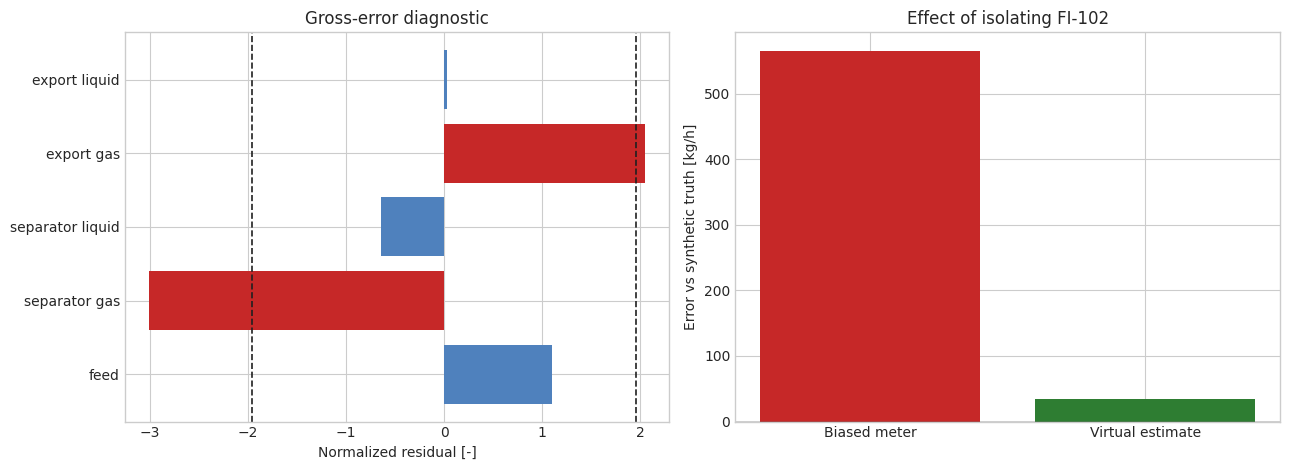

In [13]:
figure, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

residual_colors = [
    "#c62828" if abs(value) > GROSS_ERROR_THRESHOLD else "#4f81bd"
    for value in biased_normalized_residuals
]
axes[0].barh(
    [name.replace("_", " ") for name in reconciliation_names],
    biased_normalized_residuals,
    color=residual_colors,
)
axes[0].axvline(
    GROSS_ERROR_THRESHOLD,
    color="#202020",
    linestyle="--",
    linewidth=1.2,
)
axes[0].axvline(
    -GROSS_ERROR_THRESHOLD,
    color="#202020",
    linestyle="--",
    linewidth=1.2,
)
axes[0].set_xlabel("Normalized residual [-]")
axes[0].set_title("Gross-error diagnostic")

comparison_labels = ["Biased meter", "Virtual estimate"]
comparison_errors = [
    biased_meter_error_kg_h,
    virtual_meter_error_kg_h,
]
axes[1].bar(
    comparison_labels,
    comparison_errors,
    color=["#c62828", "#2e7d32"],
)
axes[1].axhline(0.0, color="#202020", linewidth=1.0)
axes[1].set_ylabel("Error vs synthetic truth [kg/h]")
axes[1].set_title("Effect of isolating FI-102")

figure.tight_layout()
gross_error_figure_path = store_figure(
    figure,
    "04_gross_error_isolation.png",
)

### Interpretation of the gross-error case

**Observation.** The global test fails. FI-102 has the largest absolute normalized residual, and
the downstream gas meter is also flagged because both participate in the conflicting gas-path
constraint. After FI-102 is removed from the estimation set, the reduced network passes and its
virtual gas estimate is much closer to the known synthetic truth.

**Physical mechanism.** One biased meter violates two independent balances. Redundancy localizes
the inconsistency, but correlated errors, leaks, inventory change, or an incorrect topology could
produce a similar residual pattern.

**Engineering implication.** `reconcileWithGrossErrorElimination` is a diagnostic aid. Isolation is
a governed decision: preserve the raw tag, record why it was excluded, and calculate any substitute
from an explicit reduced model.

**Recommendation.** Confirm the candidate against instrument diagnostics, downstream meters,
maintenance history, and process context before declaring a sensor fault. Do not write reconciled
values back to the historian as if they were raw measurements.

## 7. Calibrate a compressor model with native NeqSim estimation

The reconciliation example established which measurements can be trusted. The next model isolates
an export compressor so its polytropic efficiency can be estimated from discharge temperature at
several pressure ratios.

The synthetic plant is generated with $\eta_{\mathrm{true}}=0.78$ and Gaussian temperature noise
of $\sigma_T=0.25$ K. Eight points are used for calibration and four distinct pressures are held
back. The model uses SRK with the classic mixing rule, a 40,000 kg/h dry-rich-gas feed at 45 bara
and 20 °C, and a single-stage polytropic compressor.

In [14]:
calibration_composition_mol_pct = {
    "nitrogen": 1.2,
    "CO2": 2.2,
    "methane": 78.0,
    "ethane": 10.0,
    "propane": 5.0,
    "i-butane": 1.4,
    "n-butane": 2.2,
}


def build_calibration_process():
    calibration_fluid = SystemSrkEos(20.0 + 273.15, 45.0)
    composition_sum = sum(calibration_composition_mol_pct.values())
    for component, mole_percent in calibration_composition_mol_pct.items():
        calibration_fluid.addComponent(
            component,
            float(mole_percent / composition_sum),
        )
    calibration_fluid.setMixingRule("classic")

    calibration_feed = Stream("calibration_feed", calibration_fluid)
    calibration_feed.setFlowRate(40000.0, "kg/hr")
    calibration_feed.setTemperature(20.0, "C")
    calibration_feed.setPressure(45.0, "bara")

    calibration_compressor = Compressor(
        "calibration_compressor",
        calibration_feed,
    )
    calibration_compressor.setUsePolytropicCalc(True)
    calibration_compressor.setPolytropicEfficiency(
        TRUE_POLYTROPIC_EFFICIENCY
    )
    calibration_compressor.setOutletPressure(100.0, "bara")

    calibration_process = ProcessSystem("compressor_calibration_process")
    calibration_process.add(calibration_feed)
    calibration_process.add(calibration_compressor)
    calibration_process.run()

    return calibration_process, calibration_feed, calibration_compressor


(
    calibration_process,
    calibration_feed,
    calibration_compressor,
) = build_calibration_process()


def evaluate_calibration_compressor(efficiency, outlet_pressure_bara):
    calibration_compressor.setPolytropicEfficiency(float(efficiency))
    calibration_compressor.setOutletPressure(
        float(outlet_pressure_bara),
        "bara",
    )
    calibration_process.run()
    outlet_temperature_K = float(
        calibration_compressor.getOutletStream().getTemperature()
    )
    compressor_power_MW = float(
        calibration_compressor.getPower("MW")
    )
    return outlet_temperature_K, compressor_power_MW


training_pressures_bara = np.array(
    [75.0, 82.0, 89.0, 96.0, 103.0, 110.0, 117.0, 124.0]
)
holdout_pressures_bara = np.array([78.5, 92.5, 106.5, 125.0])
all_calibration_pressures_bara = np.concatenate(
    [training_pressures_bara, holdout_pressures_bara]
)

calibration_rng = np.random.default_rng(RANDOM_SEED + 1)
synthetic_true_temperature_K = []
synthetic_measured_temperature_K = []
synthetic_true_power_MW = []

for outlet_pressure_bara in all_calibration_pressures_bara:
    true_temperature_K, true_power_MW = evaluate_calibration_compressor(
        TRUE_POLYTROPIC_EFFICIENCY,
        outlet_pressure_bara,
    )
    measured_temperature_K = true_temperature_K + calibration_rng.normal(
        0.0,
        TEMPERATURE_NOISE_K,
    )
    synthetic_true_temperature_K.append(true_temperature_K)
    synthetic_measured_temperature_K.append(measured_temperature_K)
    synthetic_true_power_MW.append(true_power_MW)

synthetic_true_temperature_K = np.asarray(
    synthetic_true_temperature_K,
    dtype=float,
)
synthetic_measured_temperature_K = np.asarray(
    synthetic_measured_temperature_K,
    dtype=float,
)
synthetic_true_power_MW = np.asarray(
    synthetic_true_power_MW,
    dtype=float,
)

calibration_role = np.array(
    ["Training"] * len(training_pressures_bara)
    + ["Holdout"] * len(holdout_pressures_bara)
)
calibration_data_table = pd.DataFrame(
    {
        "Role": calibration_role,
        "Discharge pressure [bara]": all_calibration_pressures_bara,
        "True outlet temperature [°C]": (
            synthetic_true_temperature_K - 273.15
        ),
        "Measured outlet temperature [°C]": (
            synthetic_measured_temperature_K - 273.15
        ),
        "Measurement error [K]": (
            synthetic_measured_temperature_K
            - synthetic_true_temperature_K
        ),
        "True compressor power [MW]": synthetic_true_power_MW,
    }
)
display(calibration_data_table.round(4))

,Role,Discharge pressure [bara],True outlet temperature [°C],Measured outlet temperature [°C],Measurement error [K],True compressor power [MW]
0,Training,75.0,62.4098,62.2877,-0.1221,0.7774
1,Training,82.0,70.1376,70.1364,-0.0012,0.9266
2,Training,89.0,77.3117,77.4954,0.1836,1.0676
3,Training,96.0,84.0096,83.6522,-0.3574,1.2016
4,Training,103.0,90.2931,90.0397,-0.2534,1.3294
5,Training,110.0,96.2129,96.1467,-0.0662,1.4519
6,Training,117.0,101.8109,102.1382,0.3273,1.5695
7,Training,124.0,107.1220,107.0363,-0.0857,1.6830
8,Holdout,78.5,66.3484,65.8513,-0.4971,0.8531
9,Holdout,92.5,80.7160,80.2870,-0.4290,1.1354


In [15]:
calibration_compressor.setPolytropicEfficiency(0.66)
batch_estimator = BatchParameterEstimator(calibration_process)
batch_estimator.addTunableParameter(
    "calibration_compressor.polytropicEfficiency",
    "",
    0.55,
    0.92,
    0.66,
)
batch_estimator.addMeasuredVariable(
    "calibration_compressor.outletStream.temperature",
    "K",
    TEMPERATURE_NOISE_K,
)

for pressure_bara, measured_temperature_K in zip(
    training_pressures_bara,
    synthetic_measured_temperature_K[: len(training_pressures_bara)],
):
    conditions = HashMap()
    conditions.put(
        "calibration_compressor.outletPressure",
        jpype.JDouble(float(pressure_bara)),
    )
    measurements = HashMap()
    measurements.put(
        "calibration_compressor.outletStream.temperature",
        jpype.JDouble(float(measured_temperature_K)),
    )
    batch_estimator.addDataPoint(conditions, measurements)

batch_estimator.setMaxIterations(40)
batch_result = batch_estimator.solve()

batch_efficiency_estimate = float(batch_result.getEstimate(0))
batch_efficiency_uncertainty = float(batch_result.getUncertainty(0))
batch_chi_square = float(batch_result.getChiSquare())
batch_r_squared = float(batch_result.getRSquared())

batch_prediction_temperature_K = []
batch_prediction_power_MW = []
for pressure_bara in all_calibration_pressures_bara:
    predicted_temperature_K, predicted_power_MW = (
        evaluate_calibration_compressor(
            batch_efficiency_estimate,
            pressure_bara,
        )
    )
    batch_prediction_temperature_K.append(predicted_temperature_K)
    batch_prediction_power_MW.append(predicted_power_MW)

batch_prediction_temperature_K = np.asarray(
    batch_prediction_temperature_K,
    dtype=float,
)
batch_prediction_power_MW = np.asarray(
    batch_prediction_power_MW,
    dtype=float,
)

training_count = len(training_pressures_bara)
training_residuals_K = (
    synthetic_measured_temperature_K[:training_count]
    - batch_prediction_temperature_K[:training_count]
)
holdout_residuals_K = (
    synthetic_measured_temperature_K[training_count:]
    - batch_prediction_temperature_K[training_count:]
)
batch_training_rmse_K = float(
    np.sqrt(np.mean(np.square(training_residuals_K)))
)
batch_holdout_rmse_K = float(
    np.sqrt(np.mean(np.square(holdout_residuals_K)))
)

batch_summary_table = pd.DataFrame(
    [
        ("Synthetic true efficiency", TRUE_POLYTROPIC_EFFICIENCY, "-"),
        (
            "Native batch estimate",
            batch_efficiency_estimate,
            batch_efficiency_uncertainty,
        ),
        ("Training RMSE [K]", batch_training_rmse_K, "-"),
        ("Holdout RMSE [K]", batch_holdout_rmse_K, "-"),
        ("Batch chi-square", batch_chi_square, "-"),
        ("Batch R²", batch_r_squared, "-"),
    ],
    columns=["Metric", "Value", "Reported uncertainty"],
)
display(batch_summary_table)
print("Native estimator converged:", bool(batch_result.isConverged()))

Native estimator converged: True


,Metric,Value,Reported uncertainty
0,Synthetic true efficiency,0.780000,-
1,Native batch estimate,0.780616,0.001435
2,Training RMSE [K],0.208532,-
3,Holdout RMSE [K],0.367367,-
4,Batch chi-square,5.566167,-
5,Batch R²,0.999797,-


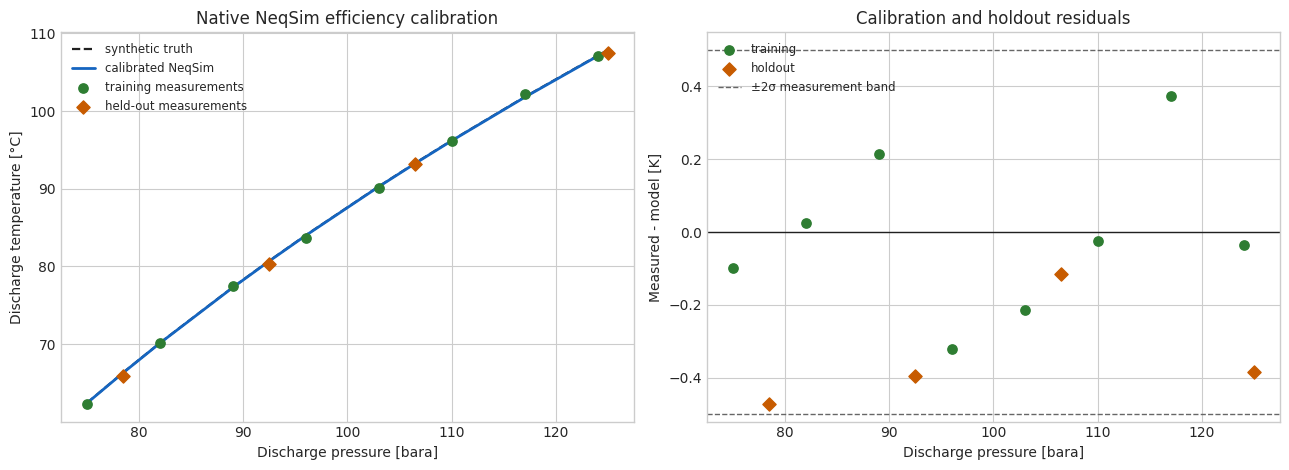

In [16]:
sort_order = np.argsort(all_calibration_pressures_bara)
sorted_pressures_bara = all_calibration_pressures_bara[sort_order]
sorted_true_temperature_C = (
    synthetic_true_temperature_K[sort_order] - 273.15
)
sorted_batch_temperature_C = (
    batch_prediction_temperature_K[sort_order] - 273.15
)

figure, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
axes[0].plot(
    sorted_pressures_bara,
    sorted_true_temperature_C,
    color="#202020",
    linestyle="--",
    linewidth=1.6,
    label="synthetic truth",
)
axes[0].plot(
    sorted_pressures_bara,
    sorted_batch_temperature_C,
    color="#1565c0",
    linewidth=2.0,
    label="calibrated NeqSim",
)
axes[0].scatter(
    training_pressures_bara,
    synthetic_measured_temperature_K[:training_count] - 273.15,
    color="#2e7d32",
    marker="o",
    s=45,
    label="training measurements",
    zorder=3,
)
axes[0].scatter(
    holdout_pressures_bara,
    synthetic_measured_temperature_K[training_count:] - 273.15,
    color="#c75b00",
    marker="D",
    s=45,
    label="held-out measurements",
    zorder=3,
)
axes[0].set_xlabel("Discharge pressure [bara]")
axes[0].set_ylabel("Discharge temperature [°C]")
axes[0].set_title("Native NeqSim efficiency calibration")
axes[0].legend(fontsize=8.5)

axes[1].axhline(0.0, color="#202020", linewidth=1.0)
axes[1].scatter(
    training_pressures_bara,
    training_residuals_K,
    color="#2e7d32",
    marker="o",
    s=45,
    label="training",
)
axes[1].scatter(
    holdout_pressures_bara,
    holdout_residuals_K,
    color="#c75b00",
    marker="D",
    s=45,
    label="holdout",
)
axes[1].axhline(
    2.0 * TEMPERATURE_NOISE_K,
    color="#666666",
    linestyle="--",
    linewidth=1.0,
)
axes[1].axhline(
    -2.0 * TEMPERATURE_NOISE_K,
    color="#666666",
    linestyle="--",
    linewidth=1.0,
    label="±2σ measurement band",
)
axes[1].set_xlabel("Discharge pressure [bara]")
axes[1].set_ylabel("Measured - model [K]")
axes[1].set_title("Calibration and holdout residuals")
axes[1].legend(fontsize=8.5)

figure.tight_layout()
batch_calibration_figure_path = store_figure(
    figure,
    "05_native_batch_calibration.png",
)

### Interpretation of native calibration

**Observation.** Starting from 0.66, the native estimator recovers an efficiency close to the
synthetic value of 0.78. Training and held-out residuals remain comparable with the 0.25 K sensor
noise, rather than improving only on calibration points.

**Physical mechanism.** At fixed suction state, a lower polytropic efficiency requires more work
and produces a hotter discharge for the same pressure ratio. Several pressure ratios identify the
shared efficiency more robustly than a single operating point.

**Engineering implication.** A high $R^2$ is not sufficient. The parameter must remain inside a
physical range, residuals need to be pattern-free, and predictions must pass on data excluded from
the fit.

**Recommendation.** Re-estimate only from reconciled steady-state windows and freeze the parameter
when inlet composition, compressor configuration, recycle position, or measurement boundaries are
uncertain.

## 8. Build and validate a NeqSim response surface

A dense Bayesian posterior would otherwise require thousands of process runs. We therefore run the
full NeqSim model at 25 efficiency anchors for every pressure, then use monotone piecewise-cubic
interpolation only between those calculated anchors. Five off-grid efficiencies are rerun directly
in NeqSim to quantify interpolation error before Bayesian inference starts.

In [17]:
model_pressures_bara = np.sort(all_calibration_pressures_bara)
efficiency_anchors = np.linspace(0.70, 0.86, 25)

temperature_anchor_K = np.empty(
    (len(model_pressures_bara), len(efficiency_anchors)),
    dtype=float,
)
power_anchor_MW = np.empty_like(temperature_anchor_K)

for pressure_index, pressure_bara in enumerate(model_pressures_bara):
    for efficiency_index, efficiency in enumerate(efficiency_anchors):
        temperature_K, power_MW = evaluate_calibration_compressor(
            efficiency,
            pressure_bara,
        )
        temperature_anchor_K[pressure_index, efficiency_index] = (
            temperature_K
        )
        power_anchor_MW[pressure_index, efficiency_index] = power_MW

temperature_surrogate = PchipInterpolator(
    efficiency_anchors,
    temperature_anchor_K,
    axis=1,
)
power_surrogate = PchipInterpolator(
    efficiency_anchors,
    power_anchor_MW,
    axis=1,
)

off_grid_efficiencies = np.array([0.713, 0.747, 0.781, 0.819, 0.853])
temperature_emulator_errors_K = []
power_emulator_errors_MW = []

for pressure_index, pressure_bara in enumerate(model_pressures_bara):
    interpolated_temperature_K = temperature_surrogate(
        off_grid_efficiencies
    )[pressure_index]
    interpolated_power_MW = power_surrogate(
        off_grid_efficiencies
    )[pressure_index]
    for check_index, efficiency in enumerate(off_grid_efficiencies):
        direct_temperature_K, direct_power_MW = (
            evaluate_calibration_compressor(
                efficiency,
                pressure_bara,
            )
        )
        temperature_emulator_errors_K.append(
            interpolated_temperature_K[check_index]
            - direct_temperature_K
        )
        power_emulator_errors_MW.append(
            interpolated_power_MW[check_index] - direct_power_MW
        )

maximum_temperature_emulator_error_K = float(
    np.max(np.abs(temperature_emulator_errors_K))
)
maximum_power_emulator_error_MW = float(
    np.max(np.abs(power_emulator_errors_MW))
)

emulator_validation_table = pd.DataFrame(
    [
        (
            "Discharge temperature",
            maximum_temperature_emulator_error_K,
            "K",
        ),
        (
            "Compressor power",
            maximum_power_emulator_error_MW,
            "MW",
        ),
    ],
    columns=["Response", "Maximum off-grid absolute error", "Unit"],
)
display(emulator_validation_table)

,Response,Maximum off-grid absolute error,Unit
0,Discharge temperature,9.690029e-08,K
1,Compressor power,9.194516e-10,MW


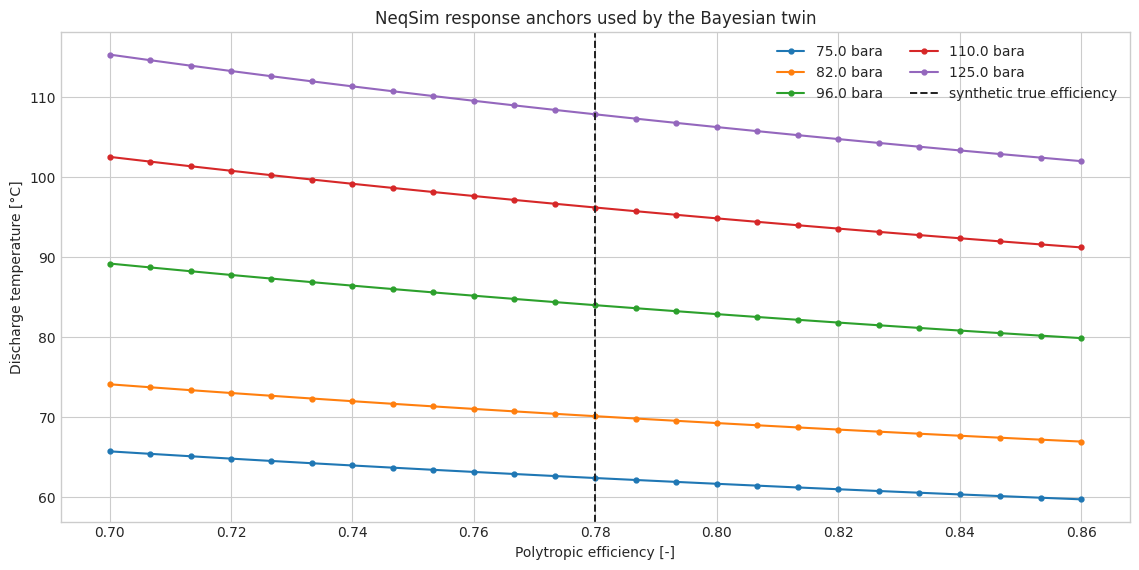

In [18]:
figure, axis = plt.subplots(figsize=(11.5, 5.8))
selected_pressure_indices = np.linspace(
    0,
    len(model_pressures_bara) - 1,
    5,
    dtype=int,
)

for pressure_index in selected_pressure_indices:
    axis.plot(
        efficiency_anchors,
        temperature_anchor_K[pressure_index] - 273.15,
        marker="o",
        markersize=3.5,
        linewidth=1.5,
        label=(
            f"{model_pressures_bara[pressure_index]:.1f} bara"
        ),
    )

axis.axvline(
    TRUE_POLYTROPIC_EFFICIENCY,
    color="#202020",
    linestyle="--",
    linewidth=1.4,
    label="synthetic true efficiency",
)
axis.set_xlabel("Polytropic efficiency [-]")
axis.set_ylabel("Discharge temperature [°C]")
axis.set_title("NeqSim response anchors used by the Bayesian twin")
axis.legend(ncol=2)
figure.tight_layout()

response_surface_figure_path = store_figure(
    figure,
    "06_neqsim_efficiency_response.png",
)

### Interpretation of the response surface

**Observation.** Temperature decreases smoothly as efficiency increases, and the sensitivity is
stronger at larger pressure ratio. Off-grid interpolation error is reported directly above and is
small relative to the 0.25 K measurement uncertainty.

**Physical mechanism.** More efficient compression converts less shaft work into irreversible
heating for the required pressure increase. The thermodynamic response is monotone over this
bounded range.

**Engineering implication.** A surrogate is acceptable only inside its trained domain and only
after comparison with fresh full-model calculations. Extrapolation beyond 0.70-0.86 is blocked.

**Recommendation.** Rebuild and revalidate the response surface whenever the EOS, fluid,
temperature, pressure range, compressor method, or NeqSim commit changes.

## 9. Form a Bayesian posterior and watch information accumulate

The prior is a truncated normal distribution centred at 0.76 with standard deviation 0.04 over
$0.70\leq\eta\leq0.86$. Each training temperature updates the posterior in sequence. This is a
parameter posterior conditioned on the assumed model and noise; it is not a complete model-form
uncertainty assessment.

In [19]:
dense_efficiency_grid = np.linspace(0.70, 0.86, 2001)
prior_mean = 0.76
prior_standard_deviation = 0.04

log_prior = -0.5 * np.square(
    (dense_efficiency_grid - prior_mean) / prior_standard_deviation
)
prior_mass = np.exp(log_prior - np.max(log_prior))
prior_mass /= np.sum(prior_mass)

dense_temperature_prediction_K = temperature_surrogate(
    dense_efficiency_grid
)


def find_pressure_index(pressure_bara):
    matches = np.flatnonzero(
        np.isclose(model_pressures_bara, pressure_bara)
    )
    if len(matches) != 1:
        raise KeyError(f"Pressure not found uniquely: {pressure_bara}")
    return int(matches[0])


def summarize_probability_grid(grid, probability_mass):
    normalized_mass = probability_mass / np.sum(probability_mass)
    cumulative_mass = np.cumsum(normalized_mass)
    mean_value = float(np.sum(grid * normalized_mass))
    map_value = float(grid[int(np.argmax(normalized_mass))])
    lower_value = float(np.interp(0.025, cumulative_mass, grid))
    median_value = float(np.interp(0.5, cumulative_mass, grid))
    upper_value = float(np.interp(0.975, cumulative_mass, grid))
    return {
        "mean": mean_value,
        "map": map_value,
        "lower_95": lower_value,
        "median": median_value,
        "upper_95": upper_value,
    }


sequential_summaries = []
log_posterior = log_prior.copy()

for observation_number, (
    pressure_bara,
    measured_temperature_K,
) in enumerate(
    zip(
        training_pressures_bara,
        synthetic_measured_temperature_K[:training_count],
    ),
    start=1,
):
    pressure_index = find_pressure_index(pressure_bara)
    model_temperature_K = dense_temperature_prediction_K[pressure_index]
    log_posterior += -0.5 * np.square(
        (measured_temperature_K - model_temperature_K)
        / TEMPERATURE_NOISE_K
    )
    posterior_mass_step = np.exp(
        log_posterior - np.max(log_posterior)
    )
    posterior_mass_step /= np.sum(posterior_mass_step)
    summary = summarize_probability_grid(
        dense_efficiency_grid,
        posterior_mass_step,
    )
    summary["observations"] = observation_number
    sequential_summaries.append(summary)

posterior_mass = posterior_mass_step
posterior_summary = sequential_summaries[-1]
posterior_density = posterior_mass / np.trapezoid(
    posterior_mass,
    dense_efficiency_grid,
)
prior_density = prior_mass / np.trapezoid(
    prior_mass,
    dense_efficiency_grid,
)

sequential_table = pd.DataFrame(sequential_summaries)
display(sequential_table.round(6))

posterior_result_table = pd.DataFrame(
    [
        ("Prior mean", prior_mean),
        ("Native batch estimate", batch_efficiency_estimate),
        ("Posterior mean", posterior_summary["mean"]),
        ("Posterior MAP", posterior_summary["map"]),
        ("Posterior median", posterior_summary["median"]),
        ("95% lower", posterior_summary["lower_95"]),
        ("95% upper", posterior_summary["upper_95"]),
        ("Synthetic truth", TRUE_POLYTROPIC_EFFICIENCY),
    ],
    columns=["Statistic", "Efficiency [-]"],
)
display(posterior_result_table.round(6))

,mean,map,lower_95,median,upper_95,observations
0,0.782841,0.78264,0.769832,0.782740,0.796117,1
1,0.781207,0.78112,0.772764,0.781141,0.789719,2
2,0.779112,0.77904,0.772784,0.779057,0.785443,3
3,0.781648,0.78160,0.776522,0.781599,0.786750,4
4,0.782363,0.78232,0.778069,0.782316,0.786615,5
5,0.781985,0.78200,0.778305,0.781940,0.785613,6
6,0.780472,0.78048,0.777269,0.780428,0.783616,7
7,0.780598,0.78056,0.777757,0.780555,0.783377,8


,Statistic,Efficiency [-]
0,Prior mean,0.760000
1,Native batch estimate,0.780616
2,Posterior mean,0.780598
3,Posterior MAP,0.780560
4,Posterior median,0.780555
5,95% lower,0.777757
6,95% upper,0.783377
7,Synthetic truth,0.780000


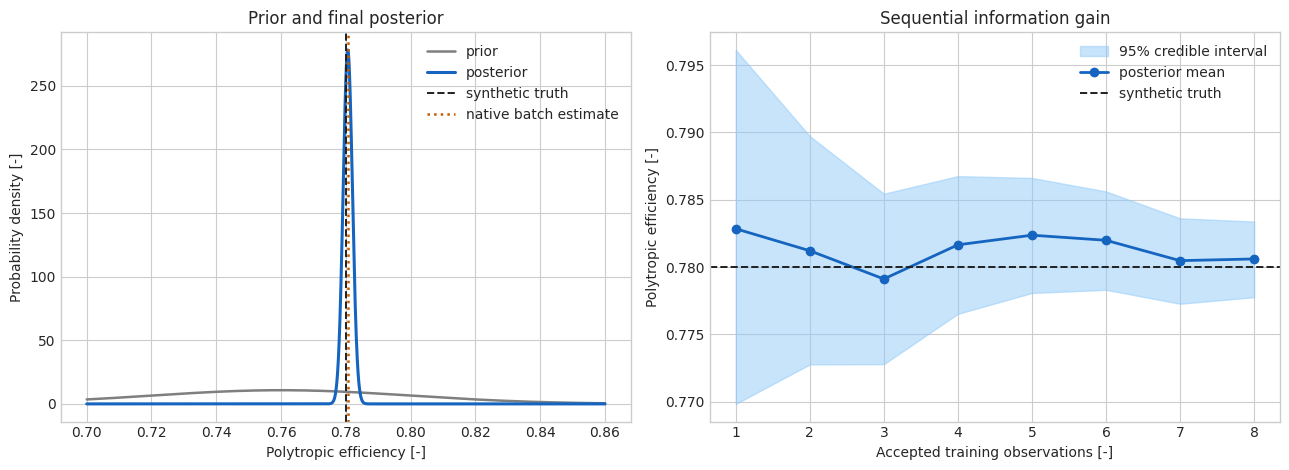

In [20]:
figure, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

axes[0].plot(
    dense_efficiency_grid,
    prior_density,
    color="#7f7f7f",
    linewidth=1.8,
    label="prior",
)
axes[0].plot(
    dense_efficiency_grid,
    posterior_density,
    color="#1565c0",
    linewidth=2.2,
    label="posterior",
)
axes[0].axvline(
    TRUE_POLYTROPIC_EFFICIENCY,
    color="#202020",
    linestyle="--",
    linewidth=1.4,
    label="synthetic truth",
)
axes[0].axvline(
    batch_efficiency_estimate,
    color="#c75b00",
    linestyle=":",
    linewidth=1.8,
    label="native batch estimate",
)
axes[0].set_xlabel("Polytropic efficiency [-]")
axes[0].set_ylabel("Probability density [-]")
axes[0].set_title("Prior and final posterior")
axes[0].legend()

observation_counts = sequential_table["observations"].to_numpy()
posterior_means = sequential_table["mean"].to_numpy()
posterior_lower = sequential_table["lower_95"].to_numpy()
posterior_upper = sequential_table["upper_95"].to_numpy()
axes[1].fill_between(
    observation_counts,
    posterior_lower,
    posterior_upper,
    color="#90caf9",
    alpha=0.5,
    label="95% credible interval",
)
axes[1].plot(
    observation_counts,
    posterior_means,
    marker="o",
    color="#1565c0",
    linewidth=2.0,
    label="posterior mean",
)
axes[1].axhline(
    TRUE_POLYTROPIC_EFFICIENCY,
    color="#202020",
    linestyle="--",
    linewidth=1.4,
    label="synthetic truth",
)
axes[1].set_xlabel("Accepted training observations [-]")
axes[1].set_ylabel("Polytropic efficiency [-]")
axes[1].set_title("Sequential information gain")
axes[1].legend()

figure.tight_layout()
posterior_figure_path = store_figure(
    figure,
    "07_bayesian_efficiency_posterior.png",
)

### Interpretation of the posterior

**Observation.** The credible interval narrows as pressure-ratio diversity is added. The final
posterior overlaps the native estimator and contains the known synthetic efficiency.

**Physical mechanism.** Each temperature removes efficiency values that cannot reproduce the
measured discharge state within stated sensor noise. Higher pressure ratios contribute more
information because temperature is more sensitive to efficiency there.

**Engineering implication.** Posterior width is conditional on the 0.25 K noise, fixed fluid,
fixed EOS, correct process topology, and absence of model discrepancy. A narrow interval can be
overconfident when those assumptions are incomplete.

**Recommendation.** Report posterior assumptions with the estimate and add nuisance parameters or
model-discrepancy terms before applying the method to a real compressor package.

## 10. Test held-out predictions with posterior uncertainty

Posterior predictive intervals combine parameter uncertainty with a new 0.25 K measurement error.
The four holdout pressures were excluded from both the native fit and Bayesian likelihood.

In [21]:
posterior_rng = np.random.default_rng(RANDOM_SEED + 2)
posterior_draw_count = 20000
posterior_draw_indices = posterior_rng.choice(
    len(dense_efficiency_grid),
    size=posterior_draw_count,
    replace=True,
    p=posterior_mass,
)

holdout_prediction_rows = []
posterior_mean_temperature_K = []

for holdout_number, pressure_bara in enumerate(holdout_pressures_bara):
    pressure_index = find_pressure_index(pressure_bara)
    temperature_by_efficiency_K = dense_temperature_prediction_K[
        pressure_index
    ]
    model_draws_K = temperature_by_efficiency_K[posterior_draw_indices]
    predictive_draws_K = model_draws_K + posterior_rng.normal(
        0.0,
        TEMPERATURE_NOISE_K,
        size=posterior_draw_count,
    )
    predictive_mean_K = float(np.mean(predictive_draws_K))
    predictive_lower_K, predictive_upper_K = np.quantile(
        predictive_draws_K,
        [0.025, 0.975],
    )
    data_index = training_count + holdout_number
    measured_temperature_K = synthetic_measured_temperature_K[data_index]
    true_temperature_K = synthetic_true_temperature_K[data_index]
    posterior_mean_temperature_K.append(predictive_mean_K)
    holdout_prediction_rows.append(
        (
            pressure_bara,
            true_temperature_K - 273.15,
            measured_temperature_K - 273.15,
            predictive_mean_K - 273.15,
            predictive_lower_K - 273.15,
            predictive_upper_K - 273.15,
            (
                predictive_lower_K
                <= measured_temperature_K
                <= predictive_upper_K
            ),
        )
    )

posterior_mean_temperature_K = np.asarray(
    posterior_mean_temperature_K,
    dtype=float,
)
holdout_prediction_table = pd.DataFrame(
    holdout_prediction_rows,
    columns=[
        "Pressure [bara]",
        "Synthetic truth [°C]",
        "Held-out measurement [°C]",
        "Posterior predictive mean [°C]",
        "Predictive 2.5% [°C]",
        "Predictive 97.5% [°C]",
        "Measurement covered",
    ],
)

posterior_holdout_residuals_K = (
    synthetic_measured_temperature_K[training_count:]
    - posterior_mean_temperature_K
)
posterior_holdout_rmse_K = float(
    np.sqrt(np.mean(np.square(posterior_holdout_residuals_K)))
)
posterior_holdout_coverage = float(
    holdout_prediction_table["Measurement covered"].mean()
)

display(holdout_prediction_table.round(4))
print("Posterior holdout RMSE [K]:", posterior_holdout_rmse_K)
print("Empirical 95% interval coverage:", posterior_holdout_coverage)

Posterior holdout RMSE [K]: 0.36818662979379674
Empirical 95% interval coverage: 1.0


,Pressure [bara],Synthetic truth [°C],Held-out measurement [°C],Posterior predictive mean [°C],Predictive 2.5% [°C],Predictive 97.5% [°C],Measurement covered
0,78.5,66.3484,65.8513,66.3257,65.8237,66.8281,True
1,92.5,80.7160,80.2870,80.6817,80.1688,81.1808,True
2,106.5,93.2956,93.1380,93.2527,92.7319,93.7692,True
3,125.0,107.8591,107.4254,107.8105,107.2717,108.3580,True


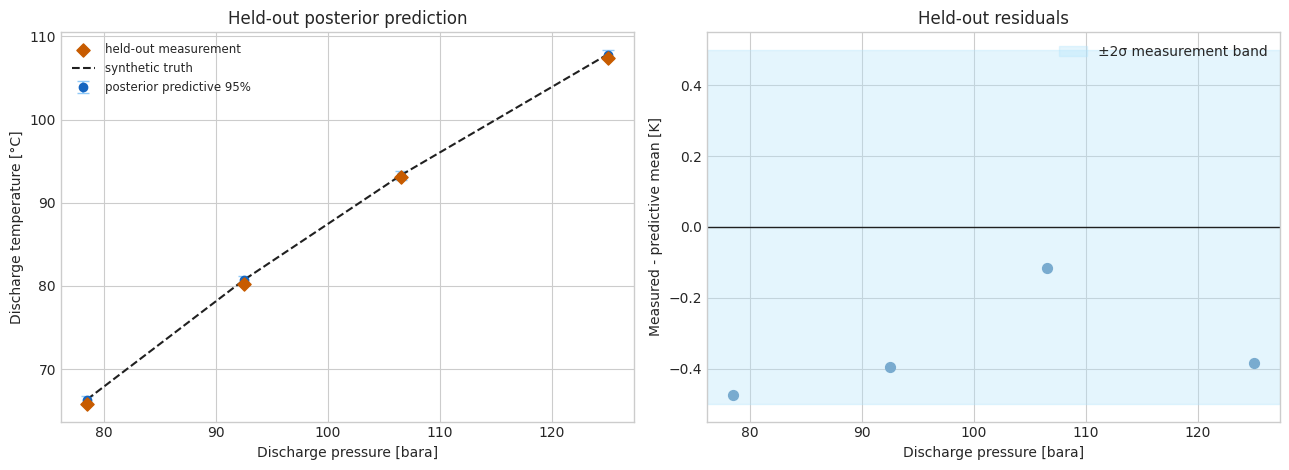

In [22]:
figure, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

holdout_measured_C = (
    synthetic_measured_temperature_K[training_count:] - 273.15
)
holdout_predictive_mean_C = posterior_mean_temperature_K - 273.15
holdout_lower_C = holdout_prediction_table[
    "Predictive 2.5% [°C]"
].to_numpy()
holdout_upper_C = holdout_prediction_table[
    "Predictive 97.5% [°C]"
].to_numpy()

axes[0].errorbar(
    holdout_pressures_bara,
    holdout_predictive_mean_C,
    yerr=[
        holdout_predictive_mean_C - holdout_lower_C,
        holdout_upper_C - holdout_predictive_mean_C,
    ],
    fmt="o",
    color="#1565c0",
    ecolor="#90caf9",
    capsize=4,
    label="posterior predictive 95%",
)
axes[0].scatter(
    holdout_pressures_bara,
    holdout_measured_C,
    marker="D",
    color="#c75b00",
    s=45,
    label="held-out measurement",
    zorder=3,
)
axes[0].plot(
    holdout_pressures_bara,
    synthetic_true_temperature_K[training_count:] - 273.15,
    color="#202020",
    linestyle="--",
    label="synthetic truth",
)
axes[0].set_xlabel("Discharge pressure [bara]")
axes[0].set_ylabel("Discharge temperature [°C]")
axes[0].set_title("Held-out posterior prediction")
axes[0].legend(fontsize=8.5)

axes[1].axhline(0.0, color="#202020", linewidth=1.0)
axes[1].scatter(
    holdout_pressures_bara,
    posterior_holdout_residuals_K,
    color="#5b8db8",
    s=50,
)
axes[1].axhspan(
    -2.0 * TEMPERATURE_NOISE_K,
    2.0 * TEMPERATURE_NOISE_K,
    color="#b3e5fc",
    alpha=0.35,
    label="±2σ measurement band",
)
axes[1].set_xlabel("Discharge pressure [bara]")
axes[1].set_ylabel("Measured - predictive mean [K]")
axes[1].set_title("Held-out residuals")
axes[1].legend()

figure.tight_layout()
holdout_figure_path = store_figure(
    figure,
    "08_holdout_posterior_prediction.png",
)

### Interpretation of holdout validation

**Observation.** The posterior predictive means track all four unseen pressure cases, and the table
reports whether each held-out measurement falls inside its calculated 95% interval.

**Physical mechanism.** Parameter uncertainty moves the NeqSim temperature response, while a fresh
noise draw represents the expected scatter of a future sensor observation.

**Engineering implication.** Holdout agreement tests transport across the chosen pressure range.
It does not test a new fluid, suction state, compressor speed, recycle condition, or degradation
mechanism.

**Recommendation.** Use blocked time-based validation on real data so adjacent historian samples
cannot leak nearly identical conditions into both training and test sets.

## 11. Propagate efficiency uncertainty to compressor power

The final posterior is mapped through the validated NeqSim power surface. A teaching threshold of
1.70 MW at 125 bara illustrates a probabilistic decision. It is not a vendor curve, motor nameplate,
or approved operating limit.

In [23]:
dense_power_prediction_MW = power_surrogate(dense_efficiency_grid)


def weighted_quantile(values, probability_mass, quantile):
    order = np.argsort(values)
    sorted_values = values[order]
    sorted_mass = probability_mass[order]
    cumulative_mass = np.cumsum(sorted_mass)
    cumulative_mass /= cumulative_mass[-1]
    return float(np.interp(quantile, cumulative_mass, sorted_values))


power_summary_rows = []
for pressure_index, pressure_bara in enumerate(model_pressures_bara):
    power_values_MW = dense_power_prediction_MW[pressure_index]
    mean_power_MW = float(np.sum(power_values_MW * posterior_mass))
    lower_power_MW = weighted_quantile(
        power_values_MW,
        posterior_mass,
        0.025,
    )
    upper_power_MW = weighted_quantile(
        power_values_MW,
        posterior_mass,
        0.975,
    )
    power_summary_rows.append(
        (
            pressure_bara,
            mean_power_MW,
            lower_power_MW,
            upper_power_MW,
        )
    )

power_summary_table = pd.DataFrame(
    power_summary_rows,
    columns=[
        "Pressure [bara]",
        "Posterior mean power [MW]",
        "Power 2.5% [MW]",
        "Power 97.5% [MW]",
    ],
)

teaching_pressure_bara = 125.0
teaching_power_limit_MW = 1.70
teaching_pressure_index = find_pressure_index(teaching_pressure_bara)
power_at_teaching_pressure_MW = dense_power_prediction_MW[
    teaching_pressure_index
]
probability_below_teaching_limit = float(
    np.sum(
        posterior_mass[
            power_at_teaching_pressure_MW <= teaching_power_limit_MW
        ]
    )
)

display(power_summary_table.round(5))
print(
    "Posterior probability that power is at or below "
    f"{teaching_power_limit_MW:.2f} MW at "
    f"{teaching_pressure_bara:.0f} bara: "
    f"{probability_below_teaching_limit:.3f}"
)

Posterior probability that power is at or below 1.70 MW at 125 bara: 0.765


,Pressure [bara],Posterior mean power [MW],Power 2.5% [MW],Power 97.5% [MW]
0,75.0,0.77677,0.77371,0.77974
1,78.5,0.85241,0.84903,0.85570
2,82.0,0.92585,0.92215,0.92944
3,89.0,1.06673,1.06241,1.07092
4,92.5,1.13447,1.12984,1.13895
5,96.0,1.20056,1.19564,1.20534
6,103.0,1.32827,1.32276,1.33362
7,106.5,1.39006,1.38427,1.39569
8,110.0,1.45059,1.44451,1.45650
9,117.0,1.56815,1.56151,1.57460


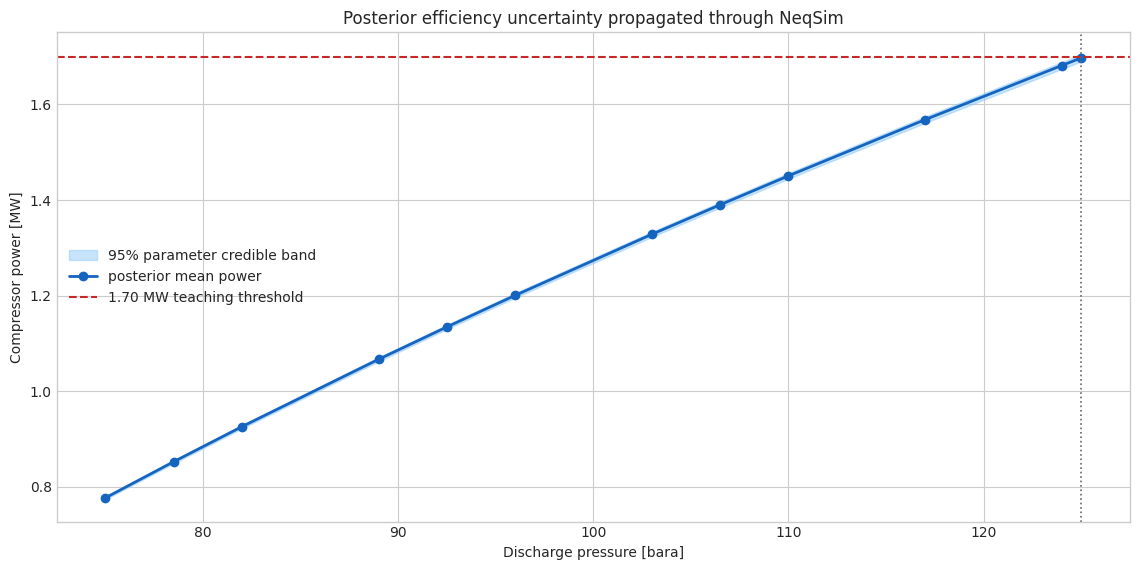

In [24]:
figure, axis = plt.subplots(figsize=(11.5, 5.8))
axis.fill_between(
    power_summary_table["Pressure [bara]"],
    power_summary_table["Power 2.5% [MW]"],
    power_summary_table["Power 97.5% [MW]"],
    color="#90caf9",
    alpha=0.5,
    label="95% parameter credible band",
)
axis.plot(
    power_summary_table["Pressure [bara]"],
    power_summary_table["Posterior mean power [MW]"],
    color="#1565c0",
    marker="o",
    linewidth=2.0,
    label="posterior mean power",
)
axis.axhline(
    teaching_power_limit_MW,
    color="#c62828",
    linestyle="--",
    linewidth=1.5,
    label="1.70 MW teaching threshold",
)
axis.axvline(
    teaching_pressure_bara,
    color="#666666",
    linestyle=":",
    linewidth=1.2,
)
axis.set_xlabel("Discharge pressure [bara]")
axis.set_ylabel("Compressor power [MW]")
axis.set_title("Posterior efficiency uncertainty propagated through NeqSim")
axis.legend()
figure.tight_layout()

power_uncertainty_figure_path = store_figure(
    figure,
    "09_power_uncertainty.png",
)

### Interpretation of the power decision

**Observation.** Power rises monotonically with discharge pressure. The credible band is narrow
because only efficiency uncertainty is propagated. The probability at 125 bara is intentionally
reported rather than collapsed into an unconditional pass/fail.

**Physical mechanism.** Higher pressure ratio raises specific compression work. Lower efficiency
raises shaft power for the same thermodynamic duty.

**Engineering implication.** A threshold decision near the posterior distribution is sensitive to
uncertainties omitted here: mass flow, suction temperature and pressure, composition, driver losses,
compressor-map position, fouling, and model discrepancy.

**Recommendation.** For design or operations, propagate all material uncertainties and compare the
full distribution with an approved compressor/driver envelope and control philosophy.

## 12. Nearby operating-point and repeatability checks

At fixed suction state, pressure ratio, and efficiency, discharge temperature should be almost
independent of mass flow in this idealized compressor calculation, while power should scale with
flow. This small perturbation check catches hidden state and unit errors before results are reused.

In [25]:
robustness_flow_rates_kg_h = np.array([38000.0, 40000.0, 42000.0])
robustness_rows = []

for flow_rate_kg_h in robustness_flow_rates_kg_h:
    calibration_feed.setFlowRate(float(flow_rate_kg_h), "kg/hr")
    temperature_K, power_MW = evaluate_calibration_compressor(
        posterior_summary["mean"],
        100.0,
    )
    robustness_rows.append(
        (
            flow_rate_kg_h,
            temperature_K - 273.15,
            power_MW,
            power_MW / flow_rate_kg_h,
        )
    )

calibration_feed.setFlowRate(40000.0, "kg/hr")
evaluate_calibration_compressor(posterior_summary["mean"], 100.0)

robustness_table = pd.DataFrame(
    robustness_rows,
    columns=[
        "Mass flow [kg/h]",
        "Discharge temperature [°C]",
        "Power [MW]",
        "Specific power [MW/(kg/h)]",
    ],
)

temperature_range_across_flow_K = float(
    robustness_table["Discharge temperature [°C]"].max()
    - robustness_table["Discharge temperature [°C]"].min()
)
specific_power_relative_range = float(
    (
        robustness_table["Specific power [MW/(kg/h)]"].max()
        - robustness_table["Specific power [MW/(kg/h)]"].min()
    )
    / robustness_table["Specific power [MW/(kg/h)]"].mean()
)

display(robustness_table.round(8))
print("Temperature range across ±5% flow [K]:", temperature_range_across_flow_K)
print("Relative specific-power range:", specific_power_relative_range)

Temperature range across ±5% flow [K]: 2.2737367544323206e-13
Relative specific-power range: 2.5526024669839986e-15


,Mass flow [kg/h],Discharge temperature [°C],Power [MW],Specific power [MW/(kg/h)]
0,38000.0,87.610883,1.210520,0.000032
1,40000.0,87.610883,1.274232,0.000032
2,42000.0,87.610883,1.337943,0.000032


## 13. Engineering validation gate

The checks below cover runtime provenance, composition, conservation, steady-state gating, native
and independent reconciliation, gross-error localization, parameter recovery, surrogate accuracy,
holdout prediction, and nearby operating-point behavior. Failure of any named check stops execution.

In [26]:
posterior_interval_width = (
    posterior_summary["upper_95"] - posterior_summary["lower_95"]
)
prior_summary = summarize_probability_grid(
    dense_efficiency_grid,
    prior_mass,
)
prior_interval_width = (
    prior_summary["upper_95"] - prior_summary["lower_95"]
)

validation_checks = {
    "source_built_reconciliation_class_loaded": (
        neqsim_source_jar.name in class_source
    ),
    "composition_normalized": (
        abs(sum(normalized_composition.values()) - 1.0) < 1.0e-12
    ),
    "separator_gas_and_liquid_are_positive": (
        true_mass_flows_kg_h["separator_gas"] > 0.0
        and true_mass_flows_kg_h["separator_liquid"] > 0.0
    ),
    "native_process_mass_balance": (
        abs(process_mass_residual_kg_h) < 1.0e-3
    ),
    "steady_state_gate_opens_after_full_window": (
        first_steady_sample >= 19
    ),
    "final_historian_window_is_steady": final_window_is_steady,
    "normal_reconciliation_converged": bool(normal_result.isConverged()),
    "normal_global_test_passed": bool(normal_result.isGlobalTestPassed()),
    "normal_constraints_close": (
        np.max(np.abs(normal_balance_after_kg_h)) < 1.0e-6
    ),
    "native_matches_independent_wls": (
        native_numpy_max_difference_kg_h < 1.0e-6
    ),
    "biased_global_test_fails": (
        not bool(biased_result.isGlobalTestPassed())
    ),
    "largest_residual_localizes_separator_gas": (
        worst_residual_tag == "separator_gas"
    ),
    "diagnostic_flags_separator_gas": (
        "separator_gas" in diagnostic_gross_errors
    ),
    "reduced_problem_passes": bool(reduced_result.isGlobalTestPassed()),
    "virtual_meter_improves_gas_estimate": (
        abs(virtual_meter_error_kg_h) < abs(biased_meter_error_kg_h)
    ),
    "native_batch_estimator_converged": bool(batch_result.isConverged()),
    "native_batch_recovers_efficiency": (
        abs(batch_efficiency_estimate - TRUE_POLYTROPIC_EFFICIENCY) < 0.01
    ),
    "native_batch_holdout_rmse_is_small": batch_holdout_rmse_K < 0.6,
    "temperature_surrogate_is_accurate": (
        maximum_temperature_emulator_error_K < 0.02
    ),
    "power_surrogate_is_accurate": (
        maximum_power_emulator_error_MW < 2.0e-4
    ),
    "posterior_contains_synthetic_truth": (
        posterior_summary["lower_95"]
        <= TRUE_POLYTROPIC_EFFICIENCY
        <= posterior_summary["upper_95"]
    ),
    "posterior_mean_recovers_efficiency": (
        abs(posterior_summary["mean"] - TRUE_POLYTROPIC_EFFICIENCY) < 0.01
    ),
    "posterior_contracts_from_prior": (
        posterior_interval_width < prior_interval_width
    ),
    "posterior_holdout_rmse_is_small": posterior_holdout_rmse_K < 0.6,
    "power_increases_with_pressure": (
        np.all(
            np.diff(
                power_summary_table["Posterior mean power [MW]"].to_numpy()
            )
            > 0.0
        )
    ),
    "flow_perturbation_preserves_temperature": (
        temperature_range_across_flow_K < 0.05
    ),
    "power_scales_with_flow": specific_power_relative_range < 0.01,
}

validation_table = pd.DataFrame(
    [
        (name, bool(passed))
        for name, passed in validation_checks.items()
    ],
    columns=["Validation check", "Passed"],
)
display(validation_table)

failed_checks = [
    name
    for name, passed in validation_checks.items()
    if not passed
]
if failed_checks:
    raise AssertionError(f"Validation checks failed: {failed_checks}")

print(
    f"Validation passed: {len(validation_checks)} / "
    f"{len(validation_checks)} named checks."
)

Validation passed: 27 / 27 named checks.


,Validation check,Passed
0,source_built_reconciliation_class_loaded,True
1,composition_normalized,True
2,separator_gas_and_liquid_are_positive,True
3,native_process_mass_balance,True
4,steady_state_gate_opens_after_full_window,True
5,final_historian_window_is_steady,True
6,normal_reconciliation_converged,True
7,normal_global_test_passed,True
8,normal_constraints_close,True
9,native_matches_independent_wls,True


## 14. Machine-readable digital-twin handoff

An operational system should pass a governed evidence object rather than an unexplained scalar.
The JSON snapshot records runtime identity, model basis, data status, reconciliation diagnostics,
parameter uncertainty, holdout performance, and the teaching decision. It also links the upstream
NeqSim example-notebook defect discovered during this work.

In [27]:
digital_twin_handoff = {
    "schema": "neqsim-colab.data-reconciliation-bayesian-twin.v1",
    "validation_date": "2026-09-01",
    "provenance": {
        "data": "deterministic synthetic teaching data",
        "neqsim_source_ref": NEQSIM_SOURCE_REF,
        "neqsim_commit": neqsim_commit,
        "neqsim_jar_sha256": neqsim_jar_sha256,
        "neqsim_python_bridge": importlib.metadata.version("neqsim"),
        "java_class_source": class_source,
    },
    "model_basis": {
        "equation_of_state": "SRK",
        "mixing_rule": "classic",
        "pressure_unit": "bara absolute",
        "mass_flow_unit": "kg/h",
        "temperature_unit": "K internally; degC for presentation",
    },
    "steady_state": {
        "window_samples": 20,
        "r_threshold": 0.5,
        "first_all_tag_steady_sample": first_steady_sample,
        "final_window_accepted": final_window_is_steady,
    },
    "reconciliation": {
        "normal_global_test_passed": bool(
            normal_result.isGlobalTestPassed()
        ),
        "normal_chi_square": float(
            normal_result.getChiSquareStatistic()
        ),
        "maximum_post_balance_residual_kg_h": float(
            np.max(np.abs(normal_balance_after_kg_h))
        ),
        "native_numpy_max_difference_kg_h": (
            native_numpy_max_difference_kg_h
        ),
        "gross_error_candidate": worst_residual_tag,
        "gross_error_flags": diagnostic_gross_errors,
        "raw_candidate_error_kg_h": biased_meter_error_kg_h,
        "virtual_meter_error_kg_h": virtual_meter_error_kg_h,
    },
    "calibration": {
        "parameter": "calibration_compressor.polytropicEfficiency",
        "synthetic_truth": TRUE_POLYTROPIC_EFFICIENCY,
        "native_batch_estimate": batch_efficiency_estimate,
        "native_reported_uncertainty": batch_efficiency_uncertainty,
        "bayesian_posterior_mean": posterior_summary["mean"],
        "bayesian_posterior_map": posterior_summary["map"],
        "bayesian_95_interval": [
            posterior_summary["lower_95"],
            posterior_summary["upper_95"],
        ],
        "holdout_rmse_K": posterior_holdout_rmse_K,
        "holdout_interval_coverage": posterior_holdout_coverage,
        "temperature_emulator_max_error_K": (
            maximum_temperature_emulator_error_K
        ),
        "power_emulator_max_error_MW": (
            maximum_power_emulator_error_MW
        ),
    },
    "teaching_decision": {
        "pressure_bara": teaching_pressure_bara,
        "power_limit_MW": teaching_power_limit_MW,
        "probability_below_limit": probability_below_teaching_limit,
        "approval_status": "educational only; no operating approval",
    },
    "validation": {
        "checks_passed": len(validation_checks),
        "checks_total": len(validation_checks),
        "failed_checks": failed_checks,
    },
    "known_upstream_issue": {
        "repository": "equinor/neqsim",
        "number": 3393,
        "url": "https://github.com/equinor/neqsim/issues/3393",
        "impact": (
            "The core example notebook uses obsolete API calls. "
            "This notebook uses and validates current signatures."
        ),
    },
}

print(json.dumps(digital_twin_handoff, indent=2))

{
  "schema": "neqsim-colab.data-reconciliation-bayesian-twin.v1",
  "validation_date": "2026-09-01",
  "provenance": {
    "data": "deterministic synthetic teaching data",
    "neqsim_source_ref": "master",
    "neqsim_commit": "fdf6b227b4240589ebbfb900527b37e667f3efc8",
    "neqsim_jar_sha256": "070494e0b9488e1c2d1f2ba75c212466346ee6c07eed950001fa5360daecfbd0",
    "neqsim_python_bridge": "3.18.0",
    "java_class_source": "file:/workspace/scratch/c5d511e6ac7e/neqsim-source/target/neqsim-3.18.0.jar"
  },
  "model_basis": {
    "equation_of_state": "SRK",
    "mixing_rule": "classic",
    "pressure_unit": "bara absolute",
    "mass_flow_unit": "kg/h",
    "temperature_unit": "K internally; degC for presentation"
  },
  "steady_state": {
    "window_samples": 20,
    "r_threshold": 0.5,
    "first_all_tag_steady_sample": 46,
    "final_window_accepted": true
  },
  "reconciliation": {
    "normal_global_test_passed": true,
    "normal_chi_square": 0.2904018361751536,
    "maximum_post_

## 15. Results summary

- NeqSim produced a two-phase inlet-separator case with explicit gas, liquid, and compressor flows.
- The native steady-state detector rejected startup and the temporary rate disturbance.
- Normal WLS reconciliation passed its global test and exactly closed three mass constraints.
- The native WLS result matched the independent NumPy equation to floating-point precision.
- A 600 kg/h FI-102 bias failed the global test and produced the largest normalized residual.
- Isolating FI-102 and using the redundant downstream gas meter greatly reduced estimation error.
- Native `BatchParameterEstimator` recovered the synthetic compressor efficiency from eight points.
- A separately calculated Bayesian posterior agreed with the native estimate and contained truth.
- Four unseen pressure points quantified out-of-sample predictive performance.
- Posterior uncertainty was propagated to compressor power and an explicitly educational threshold.

The evidence level is **conservation plus synthetic-truth recovery and holdout validation**. It is
stronger than a notebook that merely runs, but weaker than comparison with independent plant or
laboratory data.

## 16. Limitations and safe use

1. **Synthetic evidence.** Noise and bias are controlled teaching inputs, not field data.
2. **Steady-state scope.** Vessel accumulation and transport delay are excluded from WLS balances.
3. **Linear constraints.** The native example uses total-mass balances and diagonal covariance.
4. **Gross-error ambiguity.** Residual ranking localizes inconsistency but does not prove root cause.
5. **Thermodynamic model.** SRK/classic is not calibrated to a laboratory fluid in this example.
6. **Single parameter.** Efficiency may compensate for driver loss, heat loss, composition error,
   recycle configuration, or sensor bias if those effects are not modelled separately.
7. **Surrogate domain.** The PCHIP surface is accepted only for 0.70-0.86 efficiency and the shown
   pressure range; it is regenerated when the NeqSim runtime or model basis changes.
8. **Uncertainty boundary.** The power band includes efficiency only, not operating or model-form
   uncertainty.
9. **Mutable source ref.** Re-execution of `master` may resolve a newer commit; the notebook prints
   the exact commit and JAR hash for every run.
10. **Upstream example.** [NeqSim issue #3393](https://github.com/equinor/neqsim/issues/3393)
    tracks obsolete calls in the core reference notebook. The current signatures used here are
    verified directly against the loaded source-built classes.

Operational deployment requires approved tag mapping, time alignment, bad-quality handling,
covariance estimates, topology governance, independent validation, cybersecurity, access control,
change management, and accountable engineering review.

## 17. Suggested exercises

1. Add a covariance between FI-102 and FI-104 and compare with the diagonal approximation.
2. Replace the 600 kg/h bias with a leak or inventory term and examine identifiability.
3. Add separator pressure and temperature as uncertain inputs to the Bayesian model.
4. Estimate both compressor efficiency and a temperature-sensor offset; inspect correlation.
5. Perform blocked time-series cross-validation rather than pressure-point holdout.
6. Compare SRK and PR response surfaces and represent their difference as model discrepancy.
7. Replace the fixed 1.70 MW teaching threshold with a real vendor map and motor envelope.
8. Stream the JSON handoff into the IoT notebook and enforce freshness and provenance checks.
9. Use `SteadyStateDetector.createReconciliationEngine()` for a smaller one-node workflow.
10. Extend the mass network with component or energy balances and document nonlinear coupling.

## References and related notebooks

- Cao, S. and Rhinehart, R. R. (1995), *An efficient method for on-line identification of
  steady state*, Journal of Process Control 5(6), 363-374.
- Narasimhan, S. and Jordache, C. (2000), *Data Reconciliation and Gross Error Detection: An
  Intelligent Use of Process Data*, Gulf Publishing.
- [NeqSim data reconciliation and steady-state detection](https://equinor.github.io/neqsim/process/optimization/data-reconciliation)
- [NeqSim calibration documentation](https://equinor.github.io/neqsim/calibration/data_reconciliation_parameter_estimation)
- [Tracked core example repair: equinor/neqsim #3393](https://github.com/equinor/neqsim/issues/3393)
- [Digital twin model versus measurement](digital_twin_model_vs_measurement.ipynb)
- [Online process simulation](onlineprocesssimulation.ipynb)
- [IoT and Industry 4.0 with NeqSim](../AI/IoT_and_Industry4.0_with_NeqSim.ipynb)
- [Machine learning and process simulation](Machine_learning_and_process_simulation.ipynb)